In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

import warnings
# 忽略一些不必要的警告信息
warnings.filterwarnings('ignore')
# 设置随机种子以保证结果绝对可复现
np.random.seed(2026)


# 数据生成

In [130]:
# 0. 基础辅助函数定义
# ==========================================
def fill_exact_proportions(df, indices, col_name, categories, counts):
    """按精确人数分配单选题选项"""
    arr = np.concatenate([[cat] * count for cat, count in zip(categories, counts)])
    np.random.shuffle(arr)
    df.loc[indices, col_name] = arr

# 严格按照用户需求的 17 个轻食属性
attr_names = [
    '食材新鲜可靠', '健康属性解释', '配料信息标注', '门店售后服务', '包装操作方便',
    '口味与饱腹感', '高性价比', '渠道容易获取', '饮食愉悦感', '产品搭配新颖',
    '社交平台口碑', '展现健康形象', '明星公众代言', '追赶饮食潮流', '优惠会员福利',
    '舒适就餐环境', '环保低碳包装'
]

# 四类人群的关注点索引映射 (用于随机森林特征权重的底层注入)
important_attrs_by_cluster = {
    1: [0, 1, 2, 3, 4, 5, 6, 7, 8],          # 1: 高频健身塑形者
    2: [9, 10, 1, 11, 12, 13, 7, 4, 14],     # 2: 潮流健康追求者
    3: [6, 5, 0, 14, 7, 2, 3, 15, 4],        # 3: 理性价格权衡者
    4: [7, 4, 3, 14, 5, 0, 1, 15, 6]         # 4: 便利导向尝鲜者
}

# ==========================================
# 1. 初始化 DataFrame (共 809 行)与无效卷判定
# ==========================================
total_n = 809
available_n = 751
df = pd.DataFrame(index=range(total_n))

# 设定无效卷索引 (23+19+16 = 58份)
invalid_q1_idx = np.arange(0, 23)
invalid_q3_1_idx = np.arange(23, 42)
invalid_q3_2_idx = np.arange(42, 58)
valid_idx = np.arange(58, 809) # 751份有效问卷

df['问卷状态'] = '有效'
df.loc[0:57, '问卷状态'] = '无效'

df['Q1_常住居民'] = '是'
df.loc[invalid_q1_idx, 'Q1_常住居民'] = '否'

# 无效卷的Q2性别随机填充（模拟填了一半跳出），Q1选否的直接为空
df['Q2_性别'] = np.nan
df.loc[invalid_q3_1_idx.tolist() + invalid_q3_2_idx.tolist() + valid_idx.tolist(), 'Q2_性别'] = \
    np.random.choice(['男', '女'], size=19+16+available_n, p=[0.4173, 0.5827])

df['Q3_年龄'] = np.nan
df.loc[invalid_q3_1_idx, 'Q3_年龄'] = '12周岁以下'
df.loc[invalid_q3_2_idx, 'Q3_年龄'] = '70周岁以上'

# ==========================================
# 2. 填充有效问卷 (751份) - 基础信息与交叉逻辑
# ==========================================
# 加载真实前八题 CSV 数据
try:
    df_real = pd.read_csv('202602271029.csv', encoding='gbk')
    df_real.index = valid_idx  # 将CSV的 0~750 索引对齐到脚本中的 58~808
except FileNotFoundError:
    print("未找到真实数据 CSV，请确认文件名和路径！")
    exit()

# 定义数字到文本的映射字典
q2_map = {1: '男', 2: '女'}
q3_map = {1: '12周岁以下', 2: '13-18周岁', 3: '19-30周岁', 4: '31-41周岁', 5: '41-51周岁', 6: '52-62周岁', 7: '63-69周岁', 8: '70周岁以上'}
q4_map = {1: '学生', 2: '各级政府部门/事业单位领导者', 3: '专业技术人员', 4: '公司职员', 5: '自由职业者', 6: '工人工作者/其他劳动者', 7: '离/退休人员', 8: '其他'}
q5_map = {1: '3000元以下', 2: '3001-5000元', 3: '5001-8000元', 4: '8001-12000元', 5: '12001元以上'}
q6_map = {1: '高油高盐', 2: '偶尔注意', 3: '均衡不控量', 4: '主动健康', 5: '长期控制', 6: '长期控制'}
q7_map = {1: '非常了解', 2: '比较了解', 3: '不了解但愿意尝试', 4: '不了解且不愿意尝试'}
q9_map = {1: '购买过并愿意继续', 2: '购买过但不愿意继续', 3: '未购买过但愿意尝试', 4: '未购买过且对其没有兴趣'}
q10_map = {1: '一天两次或三次', 2: '一天一次', 3: '三天一次', 4: '五天一次', 5: '其他'}
q13_map = {1: '早餐', 2: '午餐', 3: '晚餐', 4: '其他'}
q14_map = {1: '15元及以下', 2: '16-25元', 3: '26-35元', 4: '36-50元', 5: '50元以上'}

# --- 注入单选题基础信息 ---
df.loc[valid_idx, 'Q1_常住居民'] = '是'
df.loc[valid_idx, 'Q2_性别'] = df_real['Q2_性别'].map(q2_map)
df.loc[valid_idx, 'Q3_年龄'] = df_real['Q3_年龄'].map(q3_map)
df.loc[valid_idx, 'Q4_职业'] = df_real['Q4_职业'].map(q4_map)
df.loc[valid_idx, 'Q5_月收入'] = df_real['Q5_月收入'].map(q5_map)
df.loc[valid_idx, 'Q6_饮食习惯'] = df_real['Q6_饮食习惯'].map(q6_map)
df.loc[valid_idx, 'Q7_轻食了解度'] = df_real['Q7_轻食了解度'].map(q7_map)

# ==========================================
# 3. 注入后半部分客观题 (Q8 - Q14) 并执行严格空值兜底
# ==========================================
# 找出所有触发了问卷提前跳过的索引，强制将后续关联题目设为 NaN
idx_q7_4 = df[df['Q7_轻食了解度'] == '不了解且不愿意尝试'].index

# --- Q8 了解渠道 ---
q8_csv_cols = ['Q8_渠道_线上购物', 'Q8_渠道_朋友推荐', 'Q8_渠道_线上外卖', 'Q8_渠道_大型超市', 'Q8_渠道_便利店', 'Q8_渠道_健身软件', 'Q8_渠道_短视频']
q8_df_cols = ['Q8_1线上购物', 'Q8_2朋友推荐', 'Q8_3线上外卖', 'Q8_4大型超市', 'Q8_5便利店', 'Q8_6健身软件', 'Q8_7短视频']
df['Q8_8其他'] = np.nan
for csv_col, df_col in zip(q8_csv_cols, q8_df_cols):
    df.loc[valid_idx, df_col] = df_real[csv_col]
# 空值兜底
for df_col in q8_df_cols + ['Q8_8其他']:
    df.loc[idx_q7_4, df_col] = np.nan

# --- Q9 购买意愿 ---
df.loc[valid_idx, 'Q9_购买意愿'] = df_real['Q9_是否购买'].map(q9_map)
df.loc[idx_q7_4, 'Q9_购买意愿'] = np.nan

# --- Q10 食用频率 ---
df.loc[valid_idx, 'Q10_食用频率'] = df_real['Q10_购买频率'].map(q10_map)
idx_q9_skip10 = df[~df['Q9_购买意愿'].isin(['购买过并愿意继续', '购买过但不愿意继续'])].index
df.loc[idx_q9_skip10, 'Q10_食用频率'] = np.nan

# --- Q11 购买原因 ---
# 注意适配 CSV 中带有逗号的特殊列名
q11_csv_cols = ['Q11_原因_食材健康', 'Q11_原因_均衡营养,', 'Q11_原因_减脂瘦身', 'Q11_原因_养身保健', 'Q11_原因_口味清淡', 'Q11_原因_烹饪简单', ',Q11_原因_颜值精致', 'Q11_原因_便于携带']
q11_df_cols = ['Q11_食材健康', 'Q11_均衡营养', 'Q11_减脂瘦身', 'Q11_养身保健', 'Q11_口味清淡', 'Q11_烹饪简单', 'Q11_颜值精致', 'Q11_便于携带']
df['Q11_其他'] = np.nan
for csv_col, df_col in zip(q11_csv_cols, q11_df_cols):
    df.loc[valid_idx, df_col] = df_real[csv_col]
idx_q9_skip11 = df[~df['Q9_购买意愿'].isin(['购买过并愿意继续', '未购买过但愿意尝试'])].index
for df_col in q11_df_cols + ['Q11_其他']:
    df.loc[idx_q9_skip11, df_col] = np.nan

# --- Q12 不选顾虑 ---
q12_csv_cols = ['Q12_顾虑_食品卫生', 'Q12_顾虑_饱腹感不足', 'Q12_顾虑_太清淡', 'Q12_顾虑_营养不均衡', 'Q12_顾虑_不愿尝鲜', 'Q12_顾虑_价格问题', 'Q12_顾虑_其他']
q12_df_cols = ['Q12_卫生问题', 'Q12_饱腹感不足', 'Q12_太清淡', 'Q12_营养不均衡', 'Q12_推广率不高', 'Q12_价格问题', 'Q12_其他']
for csv_col, df_col in zip(q12_csv_cols, q12_df_cols):
    df.loc[valid_idx, df_col] = df_real[csv_col]
# 顾虑题的触发条件：Q7选了4，或者 Q9选了2或4
idx_q12_skip = df[~((df['Q7_轻食了解度'] == '不了解且不愿意尝试') | (df['Q9_购买意愿'].isin(['购买过但不愿意继续', '未购买过且对其没有兴趣'])))].index
for df_col in q12_df_cols:
    df.loc[idx_q12_skip, df_col] = np.nan

# --- Q13 食用时段 ---
df.loc[valid_idx, 'Q13_食用时段'] = df_real['Q13_食用时段'].map(q13_map)
idx_q9_skip13 = df[~df['Q9_购买意愿'].isin(['购买过并愿意继续', '购买过但不愿意继续', '未购买过但愿意尝试'])].index
df.loc[idx_q9_skip13, 'Q13_食用时段'] = np.nan

# --- Q14 接受价格 ---
df.loc[valid_idx, 'Q14_接受价格'] = df_real['Q14_接受价格'].map(q14_map)

In [ ]:
df.describe()

In [132]:
# 4. 基于真实前14题数据的“四类核心人群”智能划定
# ==========================================
def assign_persona(row):
    """根据 MD 文件的画像特征，对每一行真实数据进行打分归类"""
    scores = {1: 0, 2: 0, 3: 0, 4: 0}
    
    # ---------------------------------
    # 人群一：核心健身人群 (The Fitness Core)
    # ---------------------------------
    if row['Q6_饮食习惯'] in ['主动健康', '长期控制']: scores[1] += 3
    if row['Q10_食用频率'] in ['一天两次或三次', '一天一次']: scores[1] += 3
    if row.get('Q11_减脂瘦身', 0) == 1: scores[1] += 2
    if row['Q14_接受价格'] in ['36-50元', '50元以上']: scores[1] += 3
    if row.get('Q8_6健身软件', 0) == 1: scores[1] += 3
    
    # ---------------------------------
    # 人群二：潮流健康追求者 (The Trendy Health Follower)
    # ---------------------------------
    if row['Q2_性别'] == '女': scores[2] += 1
    if row['Q3_年龄'] in ['13-18周岁', '19-30周岁']: scores[2] += 2
    if row.get('Q11_颜值精致', 0) == 1: scores[2] += 4
    if row.get('Q8_7短视频', 0) == 1 or row.get('Q8_2朋友推荐', 0) == 1: scores[2] += 2
    if row.get('Q12_太清淡', 0) == 1 or row.get('Q12_饱腹感不足', 0) == 1: scores[2] += 2
    
    # ---------------------------------
    # 人群三：价格敏感观望者 (The Price-Sensitive Observer)
    # ---------------------------------
    if row['Q14_接受价格'] in ['15元及以下', '16-25元']: scores[3] += 3
    if row.get('Q12_价格问题', 0) == 1: scores[3] += 5  # 核心阻碍
    if row['Q9_购买意愿'] in ['未购买过且对其没有兴趣', '购买过但不愿意继续']: scores[3] += 3
    if row['Q7_轻食了解度'] in ['不了解但愿意尝试', '不了解且不愿意尝试']: scores[3] += 2
    
    # ---------------------------------
    # 人群四：便利导向尝鲜族 (The Convenience-Oriented Dabbler)
    # ---------------------------------
    if row['Q4_职业'] in ['公司职员', '专业技术人员']: scores[4] += 2
    if row['Q13_食用时段'] == '午餐': scores[4] += 2
    if row.get('Q11_便于携带', 0) == 1 or row.get('Q11_烹饪简单', 0) == 1: scores[4] += 4
    if row.get('Q8_3线上外卖', 0) == 1: scores[4] += 3
    if row.get('Q12_卫生问题', 0) == 1: scores[4] += 2
    
    # 加入微小随机噪音防止平局
    for k in scores: scores[k] += np.random.uniform(0, 0.1)
    return max(scores, key=scores.get)

# 执划定人群
df['Persona_Cluster'] = np.nan
df.loc[valid_idx, 'Persona_Cluster'] = df.loc[valid_idx].apply(assign_persona, axis=1)

print("真实用户人群聚类分布：")
print(df['Persona_Cluster'].value_counts().rename({1:'核心健身', 2:'潮流健康', 3:'价格敏感', 4:'便利导向'}))


# ==========================================
# 5. 【千人千面】Kano 模型矩阵动态生成 (Q15-Q31)
# ==========================================
# 预设不同人群对不同属性的Kano先验认知
kano_priors_by_persona = {
    1: { # 健身人群：看重成分、配料，对营销/颜值无感
        16:'M', 17:'M', 21:'M', 15:'O', 18:'I', 20:'O', 22:'I', 23:'I', 24:'I', 25:'I', 26:'I', 27:'R', 28:'I', 29:'A', 30:'M', 31:'I'
    },
    2: { # 潮流人群：看重颜值、社交、明星、口味
        15:'O', 16:'O', 17:'M', 18:'I', 20:'A', 22:'A', 23:'A', 24:'O', 25:'A', 26:'A', 27:'A', 28:'O', 29:'A', 30:'O', 31:'A'
    },
    3: { # 价格敏感：极度看重价格和饱腹感，其他无所谓
        15:'M', 16:'I', 17:'M', 18:'M', 20:'I', 22:'I', 23:'I', 24:'I', 25:'I', 26:'I', 27:'I', 28:'I', 29:'O', 30:'O', 31:'I'
    },
    4: { # 便利导向：看重渠道好买、包装好带、卫生
        15:'O', 16:'I', 17:'M', 18:'O', 19:'M', 20:'M', 22:'I', 23:'I', 24:'I', 25:'I', 26:'I', 27:'I', 28:'O', 29:'A', 30:'M', 31:'I'
    }
}
# 兜底补充（如果有遗漏的题目默认置为 O）
for p in kano_priors_by_persona.values():
    for q in range(15, 32): p.setdefault(q, 'O')

base_scores = {'O': (5, 1), 'A': (5, 3), 'M': (4, 1), 'I': (3, 3), 'R': (1, 5)}

# 正向宽容度
df['Latent_Kano_Pos'] = np.random.choice([-1, 0, 1], 
                        size=len(df), p=[0.2, 0.6, 0.2])
# 负向苛刻度 (加大其方差，拯救低迷的负向 Alpha)
df['Latent_Kano_Neg'] = np.random.choice([-2, -1, 0, 1, 2], 
                        size=len(df), p=[0.1, 0.25, 0.3, 0.25, 0.1])

for i in range(15, 32):
    pos_col, neg_col = f'Q{i}_1正向感知', f'Q{i}_2负向感知'
    df[pos_col], df[neg_col] = np.nan, np.nan
    
    for cluster_id in [1, 2, 3, 4]:
        idx = df[df['Persona_Cluster'] == cluster_id].index
        prior = kano_priors_by_persona[cluster_id][i]
        base_p, base_n = base_scores[prior]
        
        # 增加随机噪音，把高得离谱的正向 Alpha 往下压一压
        pos_noise = np.random.choice([-1, 0, 1], size=len(idx), p=[0.25, 0.50, 0.25])
        neg_noise = np.random.choice([-1, 0, 1], size=len(idx), p=[0.20, 0.60, 0.20])
        
        pos_vals = np.clip(base_p + df.loc[idx, 'Latent_Kano_Pos'] + pos_noise, 1, 5)
        neg_vals = np.clip(base_n + df.loc[idx, 'Latent_Kano_Neg'] + neg_noise, 1, 5)
        
        # 兜底修正逻辑 (保证正向得分整体 >= 负向得分)
        mask = pos_vals < neg_vals
        pos_vals[mask], neg_vals[mask] = neg_vals[mask], pos_vals[mask]
        
        df.loc[idx, pos_col], df.loc[idx, neg_col] = pos_vals, neg_vals

df.drop(columns=['Latent_Kano_Pos', 'Latent_Kano_Neg'], inplace=True)


# ==========================================
# 6. 个性化满意度量表 (Q32, Q37) 
# ==========================================
# 根据人群赋予不同的“基础满意度”
cluster_sat_bases = {
    1: [3, 4, 4], # 健身：偏向中高
    2: [3, 4, 5], # 潮流：偏向极高（容易被满足）
    3: [2, 3, 3], # 价格敏感：整体满意度极低，吐槽较多
    4: [3, 4, 4]  # 便利导向：实用主义中等偏上
}
df['Latent_Sat'] = np.nan
for cid in [1, 2, 3, 4]:
    idx = df[df['Persona_Cluster'] == cid].index
    df.loc[idx, 'Latent_Sat'] = np.random.choice(cluster_sat_bases[cid], size=len(idx))

def generate_likert_from_latent(latent_arr):
    # 增加上下 2 分的大幅随机跳动概率，把 Alpha 压到 0.85 左右
    noise = np.random.choice([-2, -1, 0, 1, 2], size=len(latent_arr), p=[0.05, 0.25, 0.40, 0.25, 0.05])
    return np.clip(latent_arr + noise, 1, 5)

# 6.1 生成 17 个满意度自变量 (X)
for i in range(1, 18):
    attr = attr_names[i - 1]
    df[f'Q32_{i}_市场满意度'] = np.nan
    df.loc[valid_idx, f'Q32_{i}_市场满意度'] = generate_likert_from_latent(df.loc[valid_idx, 'Latent_Sat'])

# 6.2 强特征牵引：生成 总体满意度 (因变量 Y)，确保排列重要性严格递减
df['Q32_总体满意度'] = np.nan
for cid in [1, 2, 3, 4]:
    idx = df[df['Persona_Cluster'] == cid].index
    weighted_sum = np.zeros(len(idx))
    total_weight = 0
    
    # 获取当前人群设定的重点关注属性列表
    important_list = important_attrs_by_cluster[cid]
    
    for i in range(17):
        attr_col = f'Q32_{i+1}_市场满意度'
        
        # 6.2方案二：反比例/倒数衰减法 (Reciprocal Decay)
        if i in important_list:
            rank = important_list.index(i)
            # 【使用反比例衰减】：通过 (rank + 1) 的幂次来控制
            # 第1名: 20 / 1^1.2 = 20.0
            # 第2名: 20 / 2^1.2 = 8.7
            # 第3名: 20 / 3^1.2 = 5.3
            weight = 20 / ((rank + 1) ** 1.1)
        else:
            weight = 0.5
            
        weighted_sum += df.loc[idx, attr_col] * weight
        total_weight += weight
        
    overall_sat = weighted_sum / total_weight
    
    # 极小化噪音，防止排名靠后的特征（因权重太小）被噪音掩盖导致顺序错乱
    overall_sat += np.random.normal(0, 0.15, size=len(idx))
    
    df.loc[idx, 'Q32_总体满意度'] = np.clip(np.round(overall_sat), 1, 5)
    
# ==========================================
# 7. KPRO 现状与品牌方向 (Q33 - Q38)
# ==========================================
df['Q33_知道KPRO'] = np.nan
# 潮流人群(2)和便利人群(4)知道的概率极高，价格敏感(3)极低
probs_know = {1: 0.6, 2: 0.85, 3: 0.2, 4: 0.7}
for cid in [1, 2, 3, 4]:
    idx = df[df['Persona_Cluster'] == cid].index
    df.loc[idx, 'Q33_知道KPRO'] = np.random.choice(['是', '否'], size=len(idx), p=[probs_know[cid], 1-probs_know[cid]])

idx_q33_yes = df[df['Q33_知道KPRO'] == '是'].index
q34_cols = [f'Q34_{i}' for i in ['线下门店', '外卖平台', '社交媒体', '熟人推荐', '网络广告', '主动搜索', '其他']]
for col in q34_cols: df[col] = np.nan
for idx in idx_q33_yes:
    cid = df.loc[idx, 'Persona_Cluster']
    # 潮流人群必然选社交媒体，便利人群必然选外卖平台
    if cid == 2: chosen = ['Q34_社交媒体', np.random.choice(q34_cols)]
    elif cid == 4: chosen = ['Q34_外卖平台', np.random.choice(q34_cols)]
    else: chosen = np.random.choice(q34_cols, size=2, replace=False)
    for c in chosen: df.loc[idx, c] = 1
for col in q34_cols: df[col] = df[col].fillna(0).where(df['Q33_知道KPRO'] == '是', np.nan)

# Q35 买过KPRO
probs_buy = {1: 0.5, 2: 0.7, 3: 0.1, 4: 0.6}
df['Q35_买过KPRO'] = np.nan
for cid in [1, 2, 3, 4]:
    idx = df[(df['Persona_Cluster'] == cid) & (df['Q33_知道KPRO'] == '是')].index
    if len(idx)>0: df.loc[idx, 'Q35_买过KPRO'] = np.random.choice(['是', '否'], size=len(idx), p=[probs_buy[cid], 1-probs_buy[cid]])

# Q36 KPRO提升排序
idx_q35_yes = df[df['Q35_买过KPRO'] == '是'].index
q36_cols = ['Q36_1口味饱腹', 'Q36_2健康营养', 'Q36_3价格性价比', 'Q36_4品牌可见度']
for col in q36_cols: df[col] = np.nan
for idx in idx_q35_yes:
    cid = df.loc[idx, 'Persona_Cluster']
    # 精准把控排序：价格敏感肯定把价格排第1，健身人群把健康排第1
    if cid == 3: perm = [3, 4, 1, 2] # 价格第1
    elif cid == 1: perm = [3, 1, 4, 2] # 健康第1
    elif cid == 2: perm = [1, 3, 4, 2] # 口味第1
    else: perm = np.random.permutation([1, 2, 3, 4])
    df.loc[idx, q36_cols] = perm

# Q37 KPRO满意度
# 1. 圈定 KPRO 存在“进步空间”的痛点属性
improvement_attrs = [
    '高性价比', '渠道容易获取', '展现健康形象', '明星公众代言', 
    '舒适就餐环境', '口味与饱腹感', '优惠会员福利', '健康属性解释', '饮食愉悦感'
]

# 2. 为每一位有效填写者，分配一个“个人潜在满意度锚点 (Latent Anchor)”
# 它是保证 17 道题能高度相关、维持 Cronbach's Alpha > 0.85 的核心！
df['Latent_KPRO_Anchor'] = np.nan
for cid in [1, 2, 3, 4]:
    idx = df[df['Persona_Cluster'] == cid].index
    # 根据人群赋予不同的整体打分倾向（价格敏感人群整体打分偏低）
    if cid == 3:
        anchor_choices = [2, 3, 3, 4]
    else:
        anchor_choices = [3, 4, 4, 5]
    df.loc[idx, 'Latent_KPRO_Anchor'] = np.random.choice(anchor_choices, size=len(idx))

# 3. 遍历生成 17 个属性的打分
for i in range(1, 18):
    attr = attr_names[i - 1]
    col_name = f'Q37_{i}_KPRO满意度'
    df[col_name] = np.nan
    
    for idx in valid_idx:
        cid = df.loc[idx, 'Persona_Cluster']
        
        # 【关键修改 1】：以用户的内在锚点分为基准，而不是全局固定分
        expected_score = df.loc[idx, 'Latent_KPRO_Anchor']
        
        # 【关键修改 2】：全局痛点微调（适度惩罚，不要扣太多破坏一致性）
        if attr in improvement_attrs:
            expected_score -= 0.4  # 短板统一扣 0.4 分
            if attr in ['高性价比', '渠道容易获取', '明星公众代言']:
                expected_score -= 0.2  # 核心短板再扣 0.2
                
        # ---------------------------------------------------
        # 🎯 人群差异微调 (幅度控制在 0.3~0.5 之间，保护结构效度)
        # ---------------------------------------------------
        if cid == 1: # 高频健身塑形者
            if attr == '舒适就餐环境': expected_score -= 0.55
            if attr == '口味与饱腹感': expected_score -= 0.45
            if attr == '食材新鲜可靠': expected_score += 0.35
            if attr == '健康属性解释': expected_score -= 0.55
            
        elif cid == 2: # 潮流健康追求者
            if attr == '展现健康形象': expected_score -= 0.55
            if attr == '明星公众代言': expected_score -= 0.55
            if attr == '社交平台口碑': expected_score -= 0.45
            if attr == '健康属性解释': expected_score -= 0.35
            if attr == '饮食愉悦感': expected_score -= 0.25
            
        elif cid == 3: # 理性价格权衡者
            if attr == '高性价比': expected_score -= 0.65
            if attr == '优惠会员福利': expected_score -= 0.55
            if attr == '舒适就餐环境': expected_score += 0.35
            
        elif cid == 4: # 便利导向尝鲜者
            if attr == '渠道容易获取': expected_score -= 0.65
            if attr == '包装操作方便': expected_score += 0.35
            if attr == '门店售后服务': expected_score -= 0.45
            if attr == '饮食愉悦感': expected_score -= 0.35

        
        # 【关键修改 3】：大幅降低随机噪音（方差由 0.65 降至 0.35）
        # 这样既能产生浮动，又不会让各项得分偏离用户的锚点太远
        final_score = expected_score + np.random.normal(0, 0.55)
        
        # 限制在 1-5 整数范围内
        df.loc[idx, col_name] = np.clip(np.round(final_score), 1, 5)

# 清理辅助列
df.drop(columns=['Latent_KPRO_Anchor'], inplace=True)

# Q38 期望满足需求 (未买过的填写)
idx_q38 = df[(df['Q33_知道KPRO'] == '否') | (df['Q35_买过KPRO'] == '否')].index
df['Q38_期望满足需求'] = np.nan
for idx in idx_q38:
    cid = df.loc[idx, 'Persona_Cluster']
    if cid == 1: options = ['蛋白质搭配可选', '热量或营养目标可选', '是否标注营养信息']
    elif cid == 2: options = ['口味偏好可选', '酱料种类与用量可调']
    elif cid == 3: options = ['主食份量可选', '提供固定搭配套餐与自由搭配选择']
    else: options = ['食材可替换或去除', '酱料种类与用量可调', '主食份量可选']
    df.loc[idx, 'Q38_期望满足需求'] = np.random.choice(options)


df.drop(columns=['Latent_Sat'], inplace=True)



真实用户人群聚类分布：
Persona_Cluster
核心健身    242
价格敏感    227
便利导向    150
潮流健康    132
Name: count, dtype: int64


In [ ]:
# 6.2方案二：反比例/倒数衰减法 (Reciprocal Decay)
if i in important_list:
            rank = important_list.index(i)
            # 【使用反比例衰减】：通过 (rank + 1) 的幂次来控制
            # 第1名: 20 / 1^1.2 = 20.0
            # 第2名: 20 / 2^1.2 = 8.7
            # 第3名: 20 / 3^1.2 = 5.3
            weight = 20 / ((rank + 1) ** 1.2)
        else:
            weight = 0.2

In [ ]:
#6.1指数衰减
for i in range(17):
        attr_col = f'Q32_{i+1}_市场满意度'
        
        if i in important_list:
            rank = important_list.index(i)
            # 【使用指数衰减】：乘数0.65，使得相邻排名产生约1.5倍的差距
            # 第1名: 20 * 1 = 20
            # 第2名: 20 * 0.65 = 13
            # 第3名: 20 * 0.42 = 8.45
            # ... 第9名: 20 * 0.03 = 0.63
            weight = 20 * (0.65 ** rank) 
        else:
            # 非核心关注点几乎不给权重
            weight = 0.1
            
        weighted_sum += df.loc[idx, attr_col] * weight
        total_weight += weight
        
    overall_sat = weighted_sum / total_weight
    
    # 极小化噪音，防止排名靠后的特征（因权重太小）被噪音掩盖导致顺序错乱
    overall_sat += np.random.normal(0, 0.15, size=len(idx))
    
    df.loc[idx, 'Q32_总体满意度'] = np.clip(np.round(overall_sat), 1, 5)

In [133]:
df.to_csv('data_ascend.csv', index=False, encoding='utf-8-sig')
print("✅ 全部数据生成完成！已导出为 data_ascend.csv")

✅ 全部数据生成完成！已导出为 data_ascend.csv


# 信效度

In [6]:
from scipy.stats import chi2_contingency
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# ==========================================
# 0. 数据加载与预处理
# ==========================================
try:
    df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
    print(f"成功加载数据！总样本量: {len(df)}")
except FileNotFoundError:
    print("未找到数据文件，请确认文件名和路径！")
    exit()


# 筛选出有效问卷
df_valid = df[df['问卷状态'] == '有效'].copy()

# ==========================================
# 1. 信度检验 (Cronbach's Alpha)
# ==========================================
def cronbach_alpha(item_df):
    """计算克伦巴赫Alpha系数的自定义函数"""
    item_df = item_df.dropna() # 剔除缺失值
    items_count = item_df.shape[1]
    if items_count <= 1:
        return np.nan
    variance_sum = item_df.var(axis=0, ddof=1).sum()
    total_variance = item_df.sum(axis=1).var(ddof=1)
    
    if total_variance == 0:
        return 0
    alpha = (items_count / (items_count - 1)) * (1 - variance_sum / total_variance)
    return alpha

print("\n" + "="*40)
print(" 第一部分：信度检验 (Cronbach's Alpha)")
print("="*40)

# 1.1 Kano模型正向感知信度 (Q15-Q31)
q15_31_pos_cols = [f'Q{i}_1正向感知' for i in range(15, 32)]
alpha_kano_pos = cronbach_alpha(df_valid[q15_31_pos_cols])
print(f"Kano模型正向感知量表 Alpha系数: {alpha_kano_pos:.4f}")

# 1.2 Kano模型负向感知信度 (Q15-Q31)
q15_31_neg_cols = [f'Q{i}_2负向感知' for i in range(15, 32)]
alpha_kano_neg = cronbach_alpha(df_valid[q15_31_neg_cols])
print(f"Kano模型负向感知量表 Alpha系数: {alpha_kano_neg:.4f}")

# 1.3 整体市场满意度量表信度 (Q32)
q32_cols = [f'Q32_{i}_市场满意度' for i in range(1, 18)]
alpha_q32 = cronbach_alpha(df_valid[q32_cols])
print(f"整体轻食市场满意度量表(Q32) Alpha系数: {alpha_q32:.4f}")

# 1.4 KPRO满意度量表信度 (Q37) -> 注意：该题仅部分人作答，需去空
q37_cols = [f'Q37_{i}_KPRO满意度' for i in range(1, 18)]
alpha_q37 = cronbach_alpha(df_valid[q37_cols])
print(f"KPRO品牌满意度量表(Q37) Alpha系数: {alpha_q37:.4f}")


# ==========================================
# 2. 效度检验 (KMO & Bartlett球形度检验)
# ==========================================
# 注：效度检验通常用于满意度等需要提取主成分的李克特量表，Kano模型通常不需要做因子分析，所以重点测 Q32 和 Q37
print("\n" + "="*40)
print(" 第二部分：效度检验 (KMO & Bartlett检验)")
print("="*40)

def calculate_validity(item_df, scale_name):
    # 清理包含 NaN 的行
    df_clean = item_df.dropna()
    if df_clean.empty:
        print(f"[{scale_name}] 无效数据或样本量过少，无法计算效度。")
        return
    
    # Bartlett 球形度检验 (需显著, p-value < 0.05)
    chi_square_value, p_value = calculate_bartlett_sphericity(df_clean)
    
    # KMO 检验 (需 > 0.6，越接近1越好)
    kmo_all, kmo_model = calculate_kmo(df_clean)

    # 正确计算Bartlett检验的自由度
    n_vars = df_clean.shape[1]  # 题目数量
    correct_df = n_vars * (n_vars - 1) // 2  # 正确的自由度公式
    
    print(f"[{scale_name}] 效度结果:")
    print(f"  - 自由度: {correct_df}")
    print(f"  - KMO 值: {kmo_model:.4f} " + ("(极佳)" if kmo_model > 0.8 else "(良好)" if kmo_model > 0.7 else "(可接受)"))
    print(f"  - Bartlett 近似卡方值: {chi_square_value:.2f}")
    print(f"  - Bartlett 显著性 (p-value): {p_value:.4e} " + ("(显著，适合做因子分析)" if p_value < 0.05 else "(不显著)"))

calculate_validity(df_valid[q32_cols], "整体市场满意度(Q32)")
calculate_validity(df_valid[q37_cols], "KPRO满意度(Q37)")


# ==========================================
# 3. 交叉分析 (卡方检验)
# ==========================================
print("\n" + "="*40)
print(" 第三部分：交叉分析与卡方检验")
print("="*40)

def cross_analysis(df_source, col1, col2):
    """进行交叉制表和卡方独立性检验"""
    # 过滤掉两个变量中任何一个为空的数据
    df_clean = df_source[[col1, col2]].dropna()
    
    # 生成交叉频数表
    crosstab = pd.crosstab(df_clean[col1], df_clean[col2])
    print(f"\n【交叉表】 {col1} × {col2}:")
    print(crosstab)
    
    # 卡方检验
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"\n卡方值 (Chi-Square): {chi2:.4f}")
    print(f"自由度 (df): {dof}")
    print(f"P值 (p-value): {p:.4e}")
    
    if p < 0.05:
        print(f"结论: p < 0.05, 拒绝原假设，认为【{col1}】与【{col2}】之间存在显著的相关/差异关系！")
    else:
        print(f"结论: p >= 0.05, 接受原假设，认为两者相互独立，无显著关联。")

# 分析示例 1: 不同收入人群 对 轻食接受价格 是否有差异？
cross_analysis(df_valid, 'Q5_月收入', 'Q14_接受价格')

# 分析示例 2: 不同的饮食习惯 是否影响 对轻食的了解度？
cross_analysis(df_valid, 'Q6_饮食习惯', 'Q7_轻食了解度')

# 分析示例 3: 不同的年龄段 在 是否知道KPRO品牌 上是否有显著差异？
cross_analysis(df_valid, 'Q3_年龄', 'Q33_知道KPRO')

# ==========================================
# 4. 补充分析：问卷整体信效度 & Kano量表效度
# ==========================================
print("\n" + "="*50)
print(" 第四部分：整体问卷与Kano专项的信效度检验")
print("="*50)

# 定义所有面向“全员”的量表题目（Kano正向 + Kano负向 + Q32满意度）
# 注意：排除 Q37 以免因跳题逻辑导致样本量急剧丢失

all_universal_scale_cols = q15_31_pos_cols + q15_31_neg_cols + q32_cols + q37_cols

# 4.1 整体问卷信度分析
alpha_overall = cronbach_alpha(df_valid[all_universal_scale_cols])
print(f"【整体问卷量表 (Q15-Q32、Q37，共 {len(all_universal_scale_cols)} 题)】 Alpha系数: {alpha_overall:.4f}")

# 4.2 整体问卷效度分析
calculate_validity(df_valid[all_universal_scale_cols], "整体问卷量表 (Q15-Q32、Q37)")

# 4.3 Kano 量表专项效度分析
kano_all_cols = q15_31_pos_cols + q15_31_neg_cols
calculate_validity(df_valid[kano_all_cols], "Kano 总体感知量表 (正向+负向合并)")

成功加载数据！总样本量: 809

 第一部分：信度检验 (Cronbach's Alpha)
Kano模型正向感知量表 Alpha系数: 0.8998
Kano模型负向感知量表 Alpha系数: 0.9313
整体轻食市场满意度量表(Q32) Alpha系数: 0.9092
KPRO品牌满意度量表(Q37) Alpha系数: 0.9678

 第二部分：效度检验 (KMO & Bartlett检验)
[整体市场满意度(Q32)] 效度结果:
  - 自由度: 136
  - KMO 值: 0.9681 (极佳)
  - Bartlett 近似卡方值: 4219.21
  - Bartlett 显著性 (p-value): 0.0000e+00 (显著，适合做因子分析)
[KPRO满意度(Q37)] 效度结果:
  - 自由度: 136
  - KMO 值: 0.9849 (极佳)
  - Bartlett 近似卡方值: 10696.36
  - Bartlett 显著性 (p-value): 0.0000e+00 (显著，适合做因子分析)

 第三部分：交叉分析与卡方检验

【交叉表】 Q5_月收入 × Q14_接受价格:
Q14_接受价格     16-25元  26-35元  36-50元  50元以上
Q5_月收入                                    
3000元以下           0     132       0      0
3001-5000元      225       0       0      0
5001-8000元        0      75     131      0
8001-12000元       2      75      68     43

卡方值 (Chi-Square): 1076.3631
自由度 (df): 9
P值 (p-value): 5.8365e-226
结论: p < 0.05, 拒绝原假设，认为【Q5_月收入】与【Q14_接受价格】之间存在显著的相关/差异关系！

【交叉表】 Q6_饮食习惯 × Q7_轻食了解度:
Q7_轻食了解度  不了解且不愿意尝试  不了解但愿意尝试  比较了解  非常了解
Q6_饮食习惯                     

In [7]:
34*67

2278

在计算“整体问卷”的信效度时，我们必须排除 Q37（KPRO满意度）。因为根据问卷跳转逻辑，只有买过 KPRO 的人（约140人）才回答了 Q37。如果在整体检验中加入 Q37，统计软件会因为含有空值（NaN）而将未购买过 KPRO 的受访者数据全部剔除，导致您的有效样本量从 746 锐减到 140。因此，学术上对于“问卷整体信效度”，只纳入面向全员发放的量表题（即 Q15-Q31 的 Kano 题，以及 Q32 的整体市场满意度题）。

# kano

In [135]:
from IPython.core.display import HTML, display
# ==========================================
# 0. 环境设置与数据加载
# ==========================================


# 加载数据，仅取有效问卷
try:
    df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
    df_valid = df[df['问卷状态'] == '有效'].copy()
except FileNotFoundError:
    print("未找到数据文件，请先运行之前的数据生成代码！")
    exit()

# 0. 定义终端彩色输出的 ANSI 转义代码
class Colors:
    RED = '\033[91m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    BLUE = '\033[94m'
    GRAY = '\033[90m'
    RESET = '\033[0m'
    BOLD = '\033[1m'

# 1. 定义 Kano 评价矩阵与属性名称
def get_kano_category(pos, neg):
    """
    O: 期望型 (One-dimensional)
    A: 魅力型 (Attractive)
    M: 必备型 (Must-be)
    I: 无差异型 (Indifferent)
    R: 反向型 (Reverse)
    Q: 可疑结果 (Questionable)
    """
    if pd.isna(pos) or pd.isna(neg): return np.nan
    pos, neg = int(pos), int(neg)
    if pos == neg: return 'Q'
    elif pos == 5 and neg == 1: return 'O'
    elif pos == 5 and neg in [2, 3, 4]: return 'A'
    elif pos in [2, 3, 4] and neg == 1: return 'M'
    elif pos in [2, 3, 4] and neg in [2, 3, 4]: return 'I'
    else: return 'R'

kano_features = {
    15: '口味与饱腹感', 16: '配料信息标注', 17: '食材新鲜可靠', 18: '高性价比',
    19: '渠道容易获取', 20: '包装操作方便', 21: '健康属性解释', 22: '产品搭配新颖',
    23: '缓解减肥焦虑', 24: '饮食愉悦感', 25: '展现健康形象', 26: '追赶饮食潮流',
    27: '明星公众代言', 28: '社交平台口碑', 29: '优惠会员福利', 30: '门店售后服务',
    31: '舒适就餐环境'
}

# 类别全称映射字典
category_names = {
    'A': '魅力型 (A)', 'O': '期望型 (O)', 'M': '必备型 (M)',
    'I': '无差异型 (I)', 'R': '反向型 (R)', 'Q': '可疑结果 (Q)'
}

# 颜色映射字典
color_mapping = {
    'A': Colors.YELLOW, 'O': Colors.GREEN, 'M': Colors.RED,
    'I': Colors.BLUE,  'R': Colors.GRAY,   'Q': Colors.GRAY
}

# 假设 df_valid 已经在之前的步骤中成功加载
try:
    df_valid
except NameError:
    df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
    df_valid = df[df['问卷状态'] == '有效'].copy()

# 将分类结果转换为HTML格式
def create_html_colored_text(category_key, category_name):
    color_map_html = {
        'A': '#28a745',  # 绿色 - 期望型
        'O': '#ffc107',  # 黄色 - 魅力型  
        'M': '#dc3545',  # 红色 - 必备型
        'I': '#007bff',  # 蓝色 - 无差异型
        'R': '#6c757d',  # 灰色 - 反向型
        'Q': '#adb5bd'   # 浅灰色 - 可疑结果
    }
    color = color_map_html.get(category_key, '#000000')  # 默认黑色
    return f'<span style="color:{color}; font-weight:bold;">{category_name}</span>'

# 2. 计算每项属性的 Better & Worse 系数与各项占比
# ==========================================
results = []

for q_num, feature_name in kano_features.items():
    pos_col = f'Q{q_num}_1正向感知'
    neg_col = f'Q{q_num}_2负向感知'
    
    # 获取该题的所有有效分类并丢弃空值
    categories = df_valid.apply(lambda row: get_kano_category(row[pos_col], row[neg_col]), axis=1).dropna()
    total_count = len(categories)
    
    # 统计各大类的频数
    counts = categories.value_counts().to_dict()
    A, O, M, I, R, Q = (counts.get(k, 0) for k in ['A', 'O', 'M', 'I', 'R', 'Q'])
    
    # 寻找最高频次的类别，确定最终分类
    counts_dict = {'A': A, 'O': O, 'M': M, 'I': I, 'R': R, 'Q': Q}
    final_cat_key = max(counts_dict, key=counts_dict.get) # 找出频次最高的键
    
    # 生成HTML格式的分类结果
    final_classification_html = create_html_colored_text(final_cat_key, category_names[final_cat_key])
    
    # 计算 Better (SI) 和 Worse (DSI) 
    # 注意：传统的 Better-Worse 公式分母仅包含 A+O+M+I，剔除了 R 和 Q
    valid_total = A + O + M + I
    better_si = (A + O) / valid_total if valid_total > 0 else 0
    worse_dsi = (O + M) / valid_total if valid_total > 0 else 0
        
    results.append({
        '题号': f'Q{q_num}',
        '属性名称': feature_name,
        '分类结果': final_classification_html,  # 使用HTML格式的分类结果
        'Better(SI)': f"{better_si:.4f}",
        'Worse(DSI)': f"{worse_dsi:.4f}",
        'A占比': f"{A / total_count:.1%}",
        'O占比': f"{O / total_count:.1%}",
        'M占比': f"{M / total_count:.1%}",
        'I占比': f"{I / total_count:.1%}",
        'R占比': f"{R / total_count:.1%}",
        'Q占比': f"{Q / total_count:.1%}"
    })

# 转换为 DataFrame 
df_kano_results = pd.DataFrame(results)

# 打印结果表标题
print("\n" + "="*100)
print(" 整体 Kano 模型分析详细结果表")
print("="*100)

# 使用HTML显示DataFrame，使颜色生效且保持对齐
html_table = df_kano_results.to_html(escape=False, index=False)
display(HTML(html_table))


 整体 Kano 模型分析详细结果表


题号,属性名称,分类结果,Better(SI),Worse(DSI),A占比,O占比,M占比,I占比,R占比,Q占比
Q15,口味与饱腹感,期望型 (O),0.5802,0.6590,20.1%,36.8%,27.8%,13.3%,0.0%,2.0%
Q16,配料信息标注,无差异型 (I),0.3646,0.4735,16.9%,15.2%,26.5%,29.4%,0.0%,12.0%
Q17,食材新鲜可靠,必备型 (M),0.3054,0.6541,10.5%,18.6%,43.8%,22.5%,0.0%,4.5%
Q18,高性价比,无差异型 (I),0.3509,0.4519,16.4%,13.7%,25.0%,30.6%,0.0%,14.2%
Q19,渠道容易获取,期望型 (O),0.6376,0.6512,22.0%,40.3%,23.3%,12.1%,0.0%,2.3%
Q20,包装操作方便,无差异型 (I),0.5037,0.4693,22.5%,22.2%,19.4%,24.6%,0.0%,11.2%
Q21,健康属性解释,期望型 (O),0.5670,0.6401,22.1%,33.7%,29.3%,13.3%,0.0%,1.6%
Q22,产品搭配新颖,无差异型 (I),0.3390,0.2106,22.8%,3.6%,12.8%,38.6%,0.0%,22.2%
Q23,缓解减肥焦虑,无差异型 (I),0.3305,0.2226,22.5%,3.6%,14.0%,38.9%,0.0%,21.0%
Q24,饮食愉悦感,无差异型 (I),0.3133,0.3033,15.8%,9.2%,15.0%,39.8%,0.0%,20.1%


图表原理说明：

* 横坐标（Worse 系数绝对值）：代表“如果没有这项属性，用户的反感情绪有多大”。越靠右，说明该属性越是“必备”的。

* 纵坐标（Better 系数）：代表“如果提供了这项属性，用户会有多惊喜”。越靠上，说明该属性越是“加分项”。

* 十字交叉线：通常取所有属性 Better 和 Worse 的平均值来划分四个象限。

象限落点意义（可在比赛报告中重点展开）：

* 第一象限（右上，高Better、高Worse）：期望型需求 (One-dimensional)。 比如“口味与饱腹感”、“高性价比”。这类属性做好了用户很高兴，做不好极度反感。策略：倾注核心资源保持绝对优势。

* 第二象限（左上，高Better、低Worse）：魅力型需求 (Attractive)。 比如“缓解减肥焦虑”、“明星公众代言”。没有这些用户也无所谓，但一旦有了就能引发品牌自发传播。策略：作为营销破圈的亮点。

* 第三象限（左下，低Better、低Worse）：无差异型需求 (Indifferent)。 这类属性不论做不做，消费者都不怎么关心。策略：尽量削减成本，不要在此过度投入。

* 第四象限（右下，低Better、高Worse）：必备型需求 (Must-be)。 比如“食材新鲜可靠”、“配料信息标注”。做好了用户觉得理所当然（不会额外夸你），但一旦出问题（比如食材不新鲜）就会面临口碑崩塌。策略：守住底线，严控红线。

In [137]:
#from IPython.core.display import HTML, display
from IPython.display import HTML, display
from adjustText import adjust_text


try:
    df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
    df_valid = df[df['问卷状态'] == '有效'].copy()
except FileNotFoundError:
    print("未找到数据，请先运行之前生成 data_ascend.csv 的代码！")

# ==========================================
# 1. 核心定义：Kano映射、格式化与颜色
# ==========================================
def get_kano_category(pos, neg):
    if pd.isna(pos) or pd.isna(neg): return np.nan
    pos, neg = int(pos), int(neg)
    if pos == neg: return 'Q'
    elif pos == 5 and neg == 1: return 'O'
    elif pos == 5 and neg in [2, 3, 4]: return 'A'
    elif pos in [2, 3, 4] and neg == 1: return 'M'
    elif pos in [2, 3, 4] and neg in [2, 3, 4]: return 'I'
    else: return 'R'

kano_features = {
    15: '口味与饱腹感', 16: '配料信息标注', 17: '食材新鲜可靠', 18: '高性价比',
    19: '渠道容易获取', 20: '包装操作方便', 21: '健康属性解释', 22: '产品搭配新颖',
    23: '缓解减肥焦虑', 24: '饮食愉悦感', 25: '展现健康形象', 26: '追赶饮食潮流',
    27: '明星公众代言', 28: '社交平台口碑', 29: '优惠会员福利', 30: '门店售后服务',
    31: '舒适就餐环境'
}

category_names = {
    'A': '魅力型 (A)', 'O': '期望型 (O)', 'M': '必备型 (M)',
    'I': '无差异型(I)', 'R': '反向型 (R)', 'Q': '可疑结果(Q)'
}

# kano配色
color_map_hex = {
    'O': '#28a745',  # 绿色
    'A': '#ffc107',  # 黄色
    'M': '#dc3545',  # 红色
    'I': '#007bff',  # 蓝色
    'R': '#6c757d',  # 灰色
    'Q': '#adb5bd'   # 浅灰色
}

def create_html_colored_text(cat_key, cat_name):
    color = color_map_hex.get(cat_key, '#000000')
    return f'<span style="color:{color}; font-weight:bold;">{cat_name}</span>'

persona_names = {
    1: '核心健身人群',
    2: '潮流健康追求者',
    3: '价格敏感观望者',
    4: '便利导向尝鲜族'
}

# ==========================================
# 2. 循环计算并展示各人群的 Kano 详细 HTML 结果表
# ==========================================
all_results = []

for cluster_id, cluster_name in persona_names.items():
    df_cluster = df_valid[df_valid['Persona_Cluster'] == cluster_id]
    total_count = len(df_cluster)
    cluster_results = []
    
    for q_num, feature_name in kano_features.items():
        pos_col, neg_col = f'Q{q_num}_1正向感知', f'Q{q_num}_2负向感知'
        categories = df_cluster.apply(lambda row: get_kano_category(row[pos_col], row[neg_col]), axis=1).dropna()
        
        counts = categories.value_counts().to_dict()
        A, O, M, I, R, Q = (counts.get(k, 0) for k in ['A', 'O', 'M', 'I', 'R', 'Q'])
        
        counts_dict = {'A': A, 'O': O, 'M': M, 'I': I, 'R': R, 'Q': Q}
        final_cat_key = max(counts_dict, key=counts_dict.get) 
        final_html = create_html_colored_text(final_cat_key, category_names[final_cat_key])
        
        valid_total = A + O + M + I
        better_si = (A + O) / valid_total if valid_total > 0 else 0
        worse_dsi = (O + M) / valid_total if valid_total > 0 else 0
        
        res_dict = {
            '人群ID': cluster_id,
            '题号': f'Q{q_num}',
            '属性名称': feature_name,
            '分类键': final_cat_key,      # 隐藏列，用于散点图上色
            '纯文本分类': category_names[final_cat_key], # 隐藏列
            '分类结果': final_html,        # 渲染列
            'Better(SI)': f"{better_si:.4f}",
            'Worse(DSI)': f"{worse_dsi:.4f}",
            'A占比': f"{A/total_count:.1%}" if total_count else "0%",
            'O占比': f"{O/total_count:.1%}" if total_count else "0%",
            'M占比': f"{M/total_count:.1%}" if total_count else "0%",
            'I占比': f"{I/total_count:.1%}" if total_count else "0%",
            'R占比': f"{R/total_count:.1%}" if total_count else "0%",
            'Q占比': f"{Q/total_count:.1%}" if total_count else "0%"
        }
        cluster_results.append(res_dict)
        all_results.append(res_dict)
        
    # 为当前人群单独打印优美的 HTML 表格
    df_cluster_table = pd.DataFrame(cluster_results).drop(columns=['人群ID', '分类键', '纯文本分类'])
    print(f"\n【{cluster_name}】 Kano 模型 (N={total_count}人) ")
    display(HTML(df_cluster_table.to_html(escape=False, index=False)))

df_results = pd.DataFrame(all_results)


【核心健身人群】 Kano 模型 (N=242人) 


题号,属性名称,分类结果,Better(SI),Worse(DSI),A占比,O占比,M占比,I占比,R占比,Q占比
Q15,口味与饱腹感,期望型 (O),0.7333,0.6417,27.7%,45.0%,18.6%,7.9%,0.0%,0.8%
Q16,配料信息标注,必备型 (M),0.3162,0.6709,10.3%,20.2%,44.6%,21.5%,0.0%,3.3%
Q17,食材新鲜可靠,必备型 (M),0.3043,0.6826,9.9%,19.0%,45.9%,20.2%,0.0%,5.0%
Q18,高性价比,无差异型(I),0.1934,0.2044,13.6%,0.8%,14.5%,45.9%,0.0%,25.2%
Q19,渠道容易获取,期望型 (O),0.7238,0.6611,23.1%,48.3%,16.9%,10.3%,0.0%,1.2%
Q20,包装操作方便,期望型 (O),0.7303,0.6805,21.1%,51.7%,16.1%,10.7%,0.0%,0.4%
Q21,健康属性解释,必备型 (M),0.3219,0.6953,12.4%,18.6%,48.3%,16.9%,0.0%,3.7%
Q22,产品搭配新颖,无差异型(I),0.2378,0.2270,16.5%,1.7%,15.7%,42.6%,0.0%,23.6%
Q23,缓解减肥焦虑,无差异型(I),0.2022,0.2568,14.5%,0.8%,18.6%,41.7%,0.0%,24.4%
Q24,饮食愉悦感,无差异型(I),0.1989,0.1705,13.6%,0.8%,11.6%,46.7%,0.0%,27.3%



【潮流健康追求者】 Kano 模型 (N=132人) 


题号,属性名称,分类结果,Better(SI),Worse(DSI),A占比,O占比,M占比,I占比,R占比,Q占比
Q15,口味与饱腹感,期望型 (O),0.7634,0.6718,26.5%,49.2%,17.4%,6.1%,0.0%,0.8%
Q16,配料信息标注,期望型 (O),0.7500,0.6591,28.8%,46.2%,19.7%,5.3%,0.0%,0.0%
Q17,食材新鲜可靠,必备型 (M),0.3643,0.6512,9.8%,25.8%,37.9%,24.2%,0.0%,2.3%
Q18,高性价比,无差异型(I),0.2268,0.2371,15.2%,1.5%,15.9%,40.9%,0.0%,26.5%
Q19,渠道容易获取,期望型 (O),0.7786,0.6336,25.8%,51.5%,11.4%,10.6%,0.0%,0.8%
Q20,包装操作方便,魅力型 (A),0.8034,0.1709,59.8%,11.4%,3.8%,13.6%,0.0%,11.4%
Q21,健康属性解释,期望型 (O),0.7576,0.6515,23.5%,52.3%,12.9%,11.4%,0.0%,0.0%
Q22,产品搭配新颖,魅力型 (A),0.8624,0.2110,56.1%,15.2%,2.3%,9.1%,0.0%,17.4%
Q23,缓解减肥焦虑,魅力型 (A),0.8142,0.1858,56.1%,13.6%,2.3%,13.6%,0.0%,14.4%
Q24,饮食愉悦感,期望型 (O),0.6970,0.6894,22.7%,47.0%,22.0%,8.3%,0.0%,0.0%



【价格敏感观望者】 Kano 模型 (N=227人) 


题号,属性名称,分类结果,Better(SI),Worse(DSI),A占比,O占比,M占比,I占比,R占比,Q占比
Q15,口味与饱腹感,必备型 (M),0.2706,0.6881,6.6%,19.4%,46.7%,23.3%,0.0%,4.0%
Q16,配料信息标注,无差异型(I),0.2069,0.2356,15.4%,0.4%,17.6%,43.2%,0.0%,23.3%
Q17,食材新鲜可靠,必备型 (M),0.3023,0.6326,11.9%,16.7%,43.2%,22.9%,0.0%,5.3%
Q18,高性价比,必备型 (M),0.3134,0.6406,13.2%,16.7%,44.5%,21.1%,0.0%,4.4%
Q19,渠道容易获取,期望型 (O),0.7130,0.6188,27.8%,42.3%,18.5%,9.7%,0.0%,1.8%
Q20,包装操作方便,无差异型(I),0.1845,0.1964,12.3%,1.3%,13.2%,47.1%,0.0%,26.0%
Q21,健康属性解释,期望型 (O),0.6460,0.5752,29.5%,34.8%,22.5%,12.8%,0.0%,0.4%
Q22,产品搭配新颖,无差异型(I),0.1724,0.2184,11.9%,1.3%,15.4%,48.0%,0.0%,23.3%
Q23,缓解减肥焦虑,无差异型(I),0.1902,0.1957,14.1%,1.3%,14.5%,51.1%,0.0%,18.9%
Q24,饮食愉悦感,无差异型(I),0.1818,0.2102,13.2%,0.9%,15.4%,48.0%,0.0%,22.5%



【便利导向尝鲜族】 Kano 模型 (N=150人) 


题号,属性名称,分类结果,Better(SI),Worse(DSI),A占比,O占比,M占比,I占比,R占比,Q占比
Q15,口味与饱腹感,期望型 (O),0.6259,0.6327,22.7%,38.7%,23.3%,13.3%,0.0%,2.0%
Q16,配料信息标注,无差异型(I),0.2645,0.2314,19.3%,2.0%,16.7%,42.7%,0.0%,19.3%
Q17,食材新鲜可靠,必备型 (M),0.2587,0.6434,10.0%,14.7%,46.7%,24.0%,0.0%,4.7%
Q18,高性价比,期望型 (O),0.6779,0.6174,26.7%,40.7%,20.7%,11.3%,0.0%,0.7%
Q19,渠道容易获取,必备型 (M),0.2411,0.7021,8.0%,14.7%,51.3%,20.0%,0.0%,6.0%
Q20,包装操作方便,必备型 (M),0.2482,0.6809,7.3%,16.0%,48.0%,22.7%,0.0%,6.0%
Q21,健康属性解释,期望型 (O),0.6622,0.6419,25.3%,40.0%,23.3%,10.0%,0.0%,1.3%
Q22,产品搭配新颖,无差异型(I),0.2586,0.1724,20.0%,0.0%,13.3%,44.0%,0.0%,22.7%
Q23,缓解减肥焦虑,无差异型(I),0.2832,0.2478,18.7%,2.7%,16.0%,38.0%,0.0%,24.7%
Q24,饮食愉悦感,无差异型(I),0.2500,0.2069,17.3%,2.0%,14.0%,44.0%,0.0%,22.7%



 正在生成独立 Kano 四象限图...
✅ 已生成并保存高清图像: Kano_Matrix_Cluster_1.png


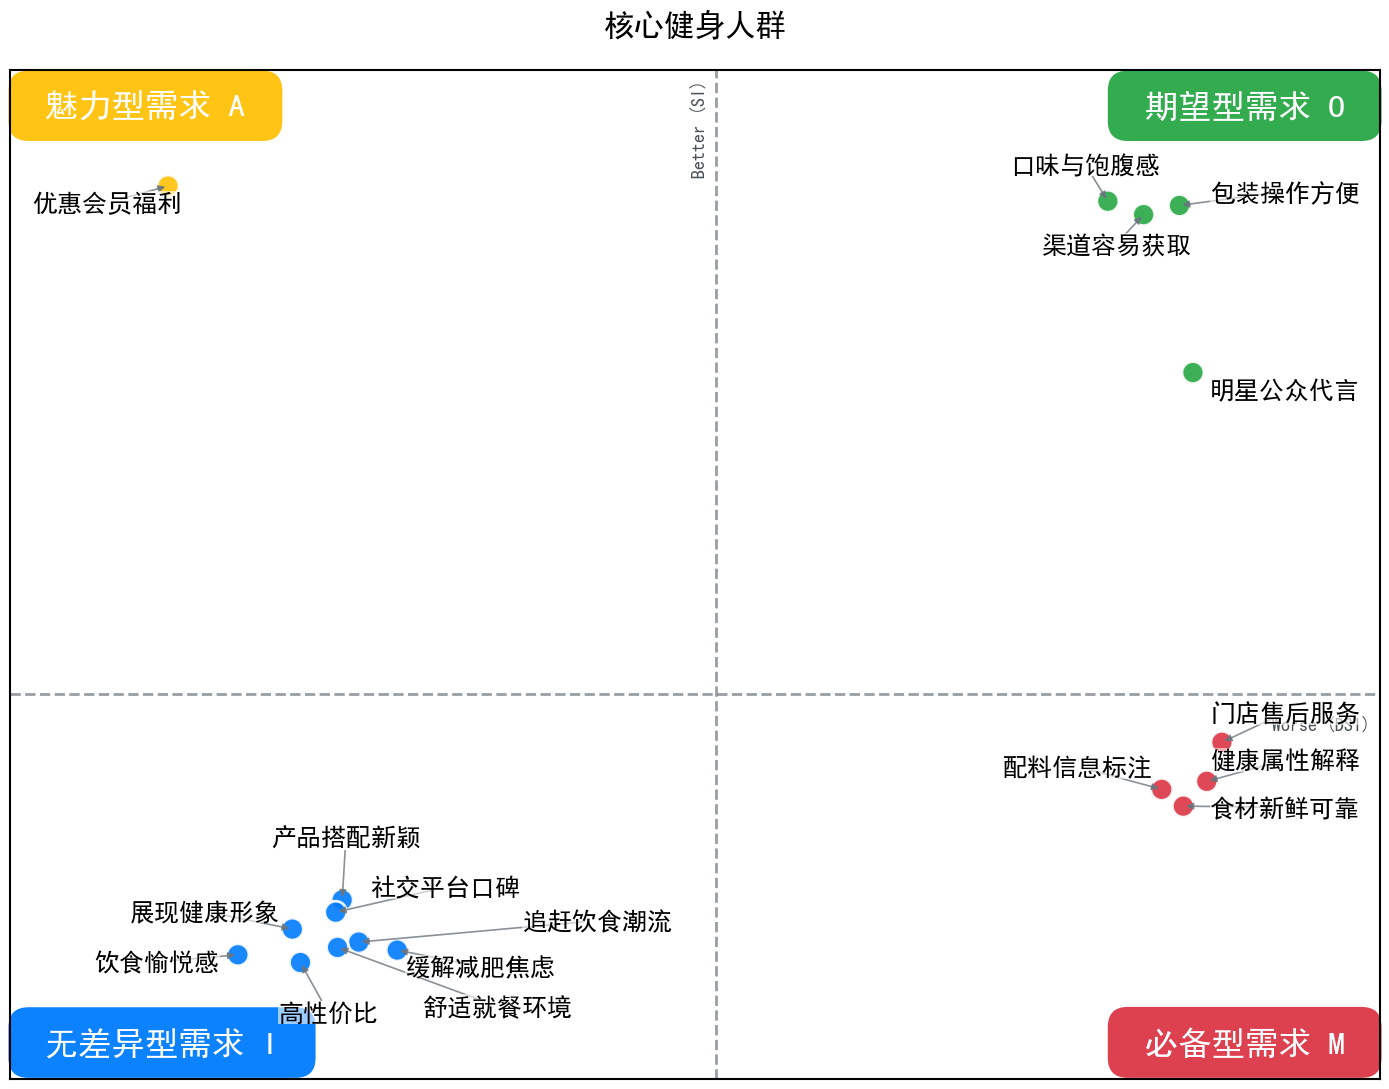

✅ 已生成并保存高清图像: Kano_Matrix_Cluster_2.png


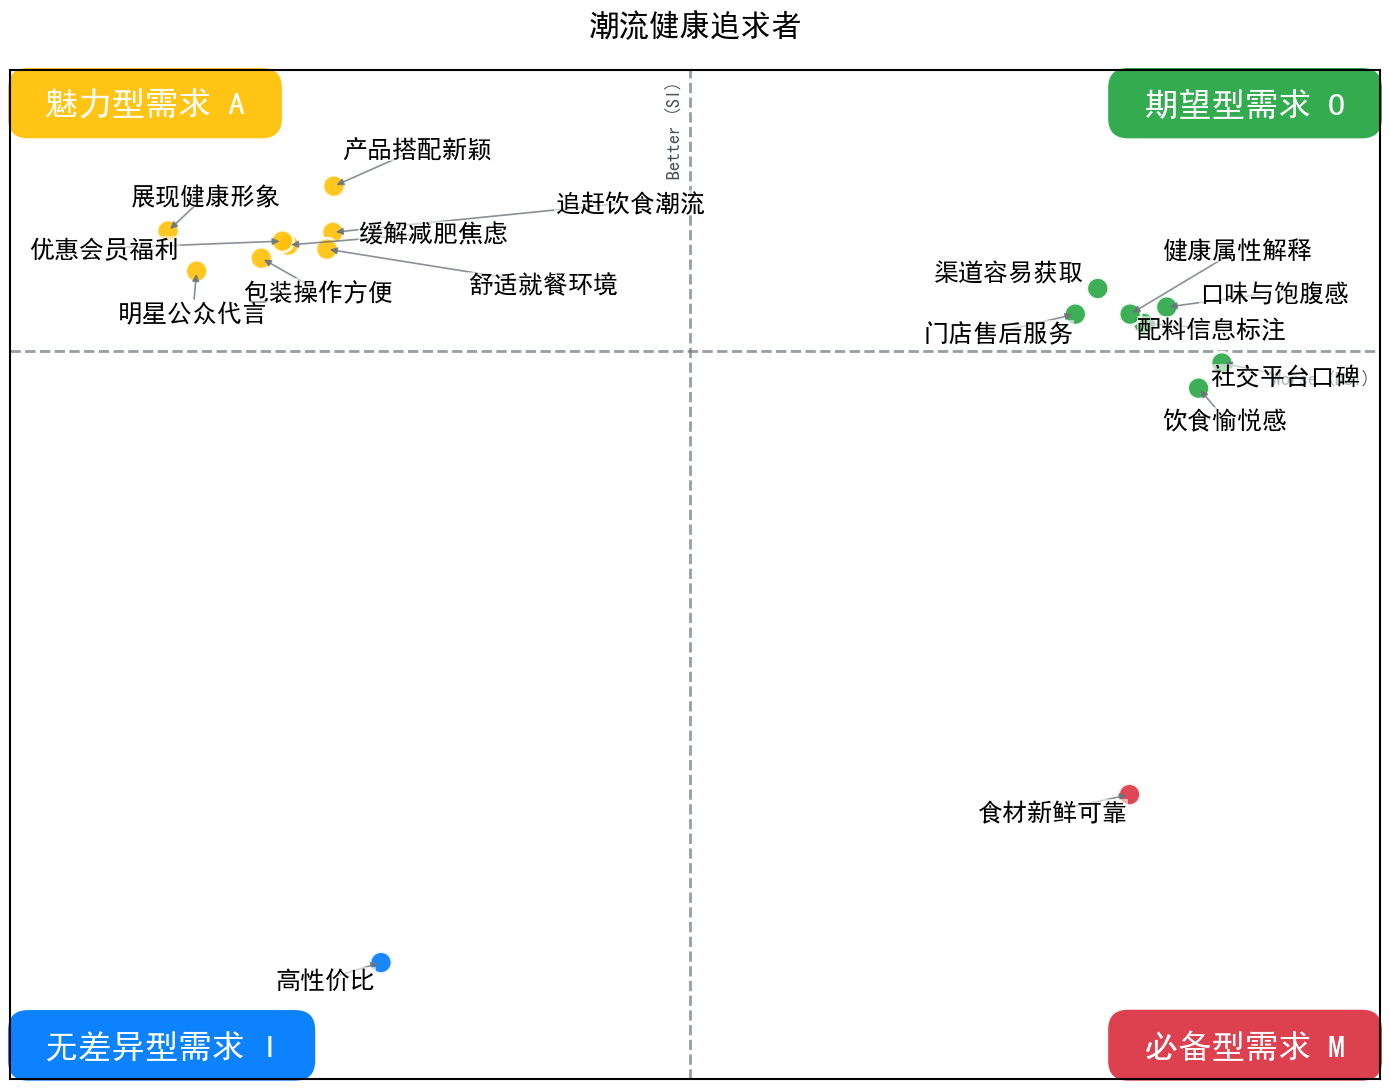

✅ 已生成并保存高清图像: Kano_Matrix_Cluster_3.png


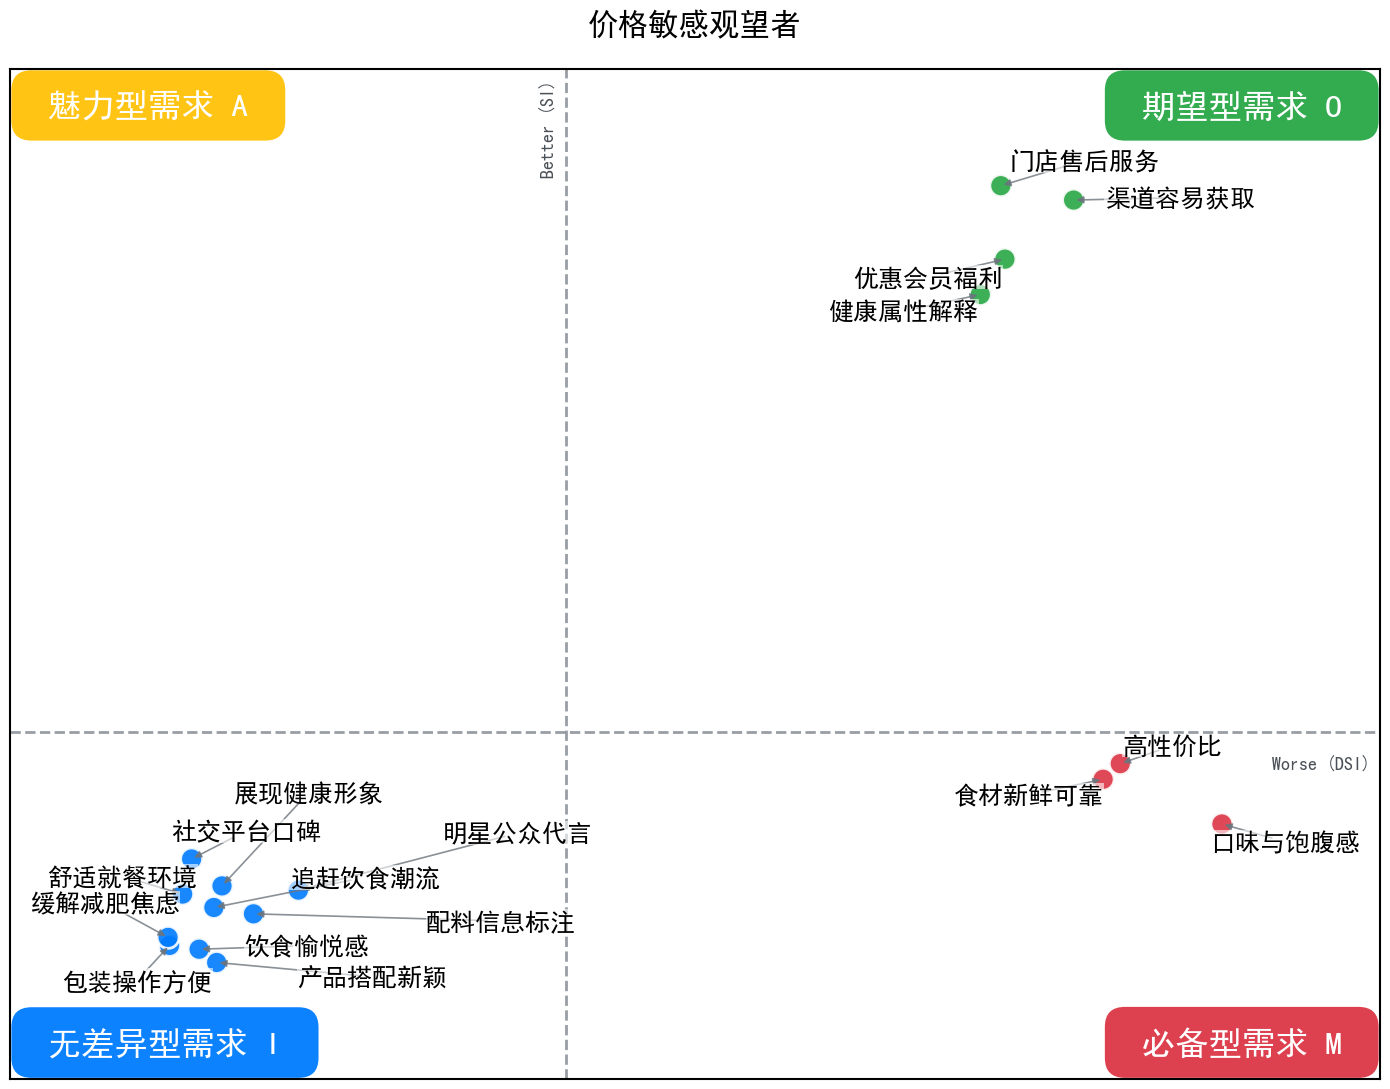

✅ 已生成并保存高清图像: Kano_Matrix_Cluster_4.png


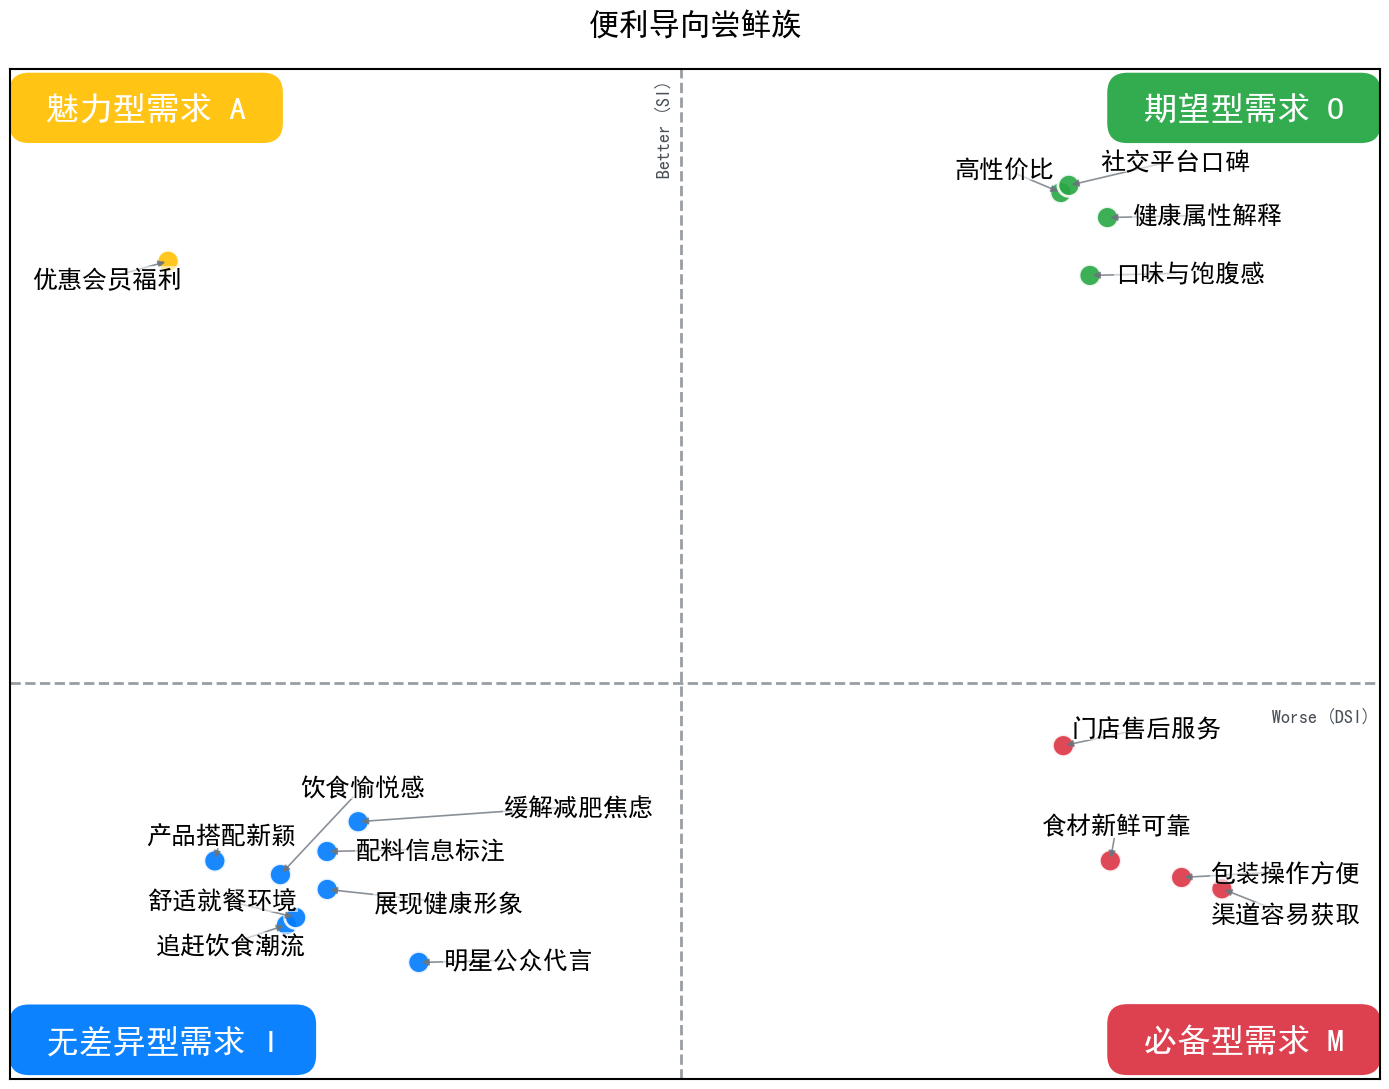


🎉 分析全部完成！详细系数值已导出为 Kano_Results_by_Persona.csv


In [138]:
# ==========================================
# 3. 绘制独立 Kano 四象限图
# ==========================================

badge_colors = {
    'O': '#28a745',  # 绿色 - 期望型
    'A': '#ffc107',  # 黄色 - 魅力型
    'M': '#dc3545',  # 红色 - 必备型
    'I': '#007bff'   # 蓝色 - 无差异型
}

print("\n" + "="*80)
print(" 正在生成独立 Kano 四象限图...")
print("="*80)

# 为每个客群独立生成一张大图
for cluster_id, cluster_name in persona_names.items():
    # 创建独立画布，尺寸调大以保证极高的可读性
    fig, ax = plt.subplots(figsize=(14, 11))
    
    # 获取当前客群数据
    df_sub = df_results[df_results['人群ID'] == cluster_id]
    x = df_sub['Worse(DSI)'].astype(float)
    y = df_sub['Better(SI)'].astype(float)
    labels = df_sub['属性名称'].tolist()
    cat_keys = df_sub['分类键'].tolist()
    point_colors = [color_map_hex[key] for key in cat_keys]
    
    # 绘制散点 (调大点的大小 s=250，增加白边粗细提升对比度)
    scatter = ax.scatter(x, y, s=250, c=point_colors, edgecolor='white', linewidth=2, alpha=0.9, zorder=3)
    
    # 获取十字交叉基准线
    mean_worse = x.mean()
    mean_better = y.mean()
    
    # 绘制十字交叉虚线 (加粗加深)
    ax.axvline(x=mean_worse, color='#6c757d', linestyle='--', linewidth=2, alpha=0.7, zorder=1)
    ax.axhline(y=mean_better, color='#6c757d', linestyle='--', linewidth=2, alpha=0.7, zorder=1)
    
    # ---------------------------------------------------------
    # 核心美化 1：去除传统坐标轴与刻度，背景纯净化
    # ---------------------------------------------------------
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)
    #ax.spines['bottom'].set_visible(False)
    #ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#ffffff') # 纯白背景

    # 激活并设置四周的边框为黑色实线
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    
    # ---------------------------------------------------------
    # 核心美化 2：将坐标轴标签直接附着在十字交叉线上
    # ---------------------------------------------------------
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    padding_x = (x_max - x_min) * 0.15
    padding_y = (y_max - y_min) * 0.15
    
    ax.set_xlim(x_min - padding_x, x_max + padding_x)
    ax.set_ylim(y_min - padding_y, y_max + padding_y)
    
    # 横轴文字放在横向虚线右侧末端
    ax.text(ax.get_xlim()[1], mean_better - 0.015, 'Worse (DSI) ', 
            fontsize=13, color='#495057', fontweight='bold', ha='right', va='top', zorder=2)
    
    # 纵轴文字放在竖向虚线顶部末端
    ax.text(mean_worse - 0.005, ax.get_ylim()[1], 'Better (SI) ', 
            fontsize=13, color='#495057', fontweight='bold', ha='right', va='top', rotation=90, zorder=2)

    # ---------------------------------------------------------
    # 核心美化 3：绘制高对比度的“彩色徽章”象限标识
    # ---------------------------------------------------------
    badge_style = dict(edgecolor='none', boxstyle='round,pad=0.6', alpha=0.95)
    
    # 期望型 (O) - 右上黄底白字
    ax.text(ax.get_xlim()[1] - 0.01, ax.get_ylim()[1] - 0.015, ' 期望型需求 O ', 
            fontsize=24, color='white', fontweight='bold', ha='right', va='top', zorder=0,
            bbox=dict(facecolor=badge_colors['O'], **badge_style))
    
    # 魅力型 (A) - 左上绿底白字
    ax.text(ax.get_xlim()[0] + 0.01, ax.get_ylim()[1] - 0.015, ' 魅力型需求 A ', 
            fontsize=24, color='white', fontweight='bold', ha='left', va='top', zorder=0,
            bbox=dict(facecolor=badge_colors['A'], **badge_style))
    
    # 必备型 (M) - 右下红底白字
    ax.text(ax.get_xlim()[1] - 0.01, ax.get_ylim()[0] + 0.015, ' 必备型需求 M ', 
            fontsize=24, color='white', fontweight='bold', ha='right', va='bottom', zorder=0,
            bbox=dict(facecolor=badge_colors['M'], **badge_style))
    
    # 无差异型 (I) - 左下蓝底白字
    ax.text(ax.get_xlim()[0] + 0.01, ax.get_ylim()[0] + 0.015, ' 无差异型需求 I ', 
            fontsize=24, color='white', fontweight='bold', ha='left', va='bottom', zorder=0,
            bbox=dict(facecolor=badge_colors['I'], **badge_style))

    # ---------------------------------------------------------
    # 核心美化 4：应用 adjustText 防重叠，加大间距与字号
    # ---------------------------------------------------------
    texts = []
    for j, label in enumerate(labels):
                # 【关键改动】：设置 ha='center', va='center'，让文字从圆心向 360 度散开
                texts.append(ax.text(x.iloc[j], y.iloc[j], label, fontsize=18, fontweight='bold', 
                                ha='center', va='center', zorder=4,
                                bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.1)))
        

        # 【关键改动】：调整弹开系数，增加文字之间的互斥力，强制呈放射状分布
    adjust_text(texts, ax=ax, 
                    arrowprops=dict(arrowstyle="-|>", color='#6c757d', lw=1.2, alpha=0.8, shrinkA=10),
                    expand_points=(2.5, 2.5), 
                    expand_text=(2.0, 2.0),
                    force_text=(0.8, 0.8),   # 增加文字与文字之间的排斥力
                    force_points=(1.0, 1.0)) # 增加文字与数据点之间的排斥力

    # 设置大标题
    ax.set_title(f'{cluster_name}', fontsize=22, fontweight='bold', pad=25)
    
    plt.tight_layout()
    
    # 自动保存为高清图片
    save_filename = f'Kano_Matrix_Cluster_{cluster_id}.png'
    plt.savefig(save_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ 已生成并保存高清图像: {save_filename}")
    
    plt.show()

# ==========================================
# 4. 导出分类结果用于查阅
# ==========================================
df_results.to_csv('Kano_Results_by_Persona.csv', index=False, encoding='utf-8-sig')
print("\n🎉 分析全部完成！详细系数值已导出为 Kano_Results_by_Persona.csv")

# 数据打乱

In [ ]:
df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')

df_shuffled = df.sample(frac=1).reset_index(drop=True)
df_shuffled.to_csv('data_shuffled.csv', index=False)

# TOPSIS排序

In [ ]:
try:
    df = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
    df_valid = df[df['问卷状态'] == '有效'].copy()
except FileNotFoundError:
    print("未找到数据，请确认文件路径！")
    exit()

def get_kano_category(pos, neg):
    if pd.isna(pos) or pd.isna(neg): return np.nan
    pos, neg = int(pos), int(neg)
    if pos == neg: return 'Q'
    elif pos == 5 and neg == 1: return 'O'
    elif pos == 5 and neg in [2, 3, 4]: return 'A'
    elif pos in [2, 3, 4] and neg == 1: return 'M'
    elif pos in [2, 3, 4] and neg in [2, 3, 4]: return 'I'
    else: return 'R'

kano_features = {
    15: '口味与饱腹感', 16: '配料信息标注', 17: '食材新鲜可靠', 18: '高性价比',
    19: '渠道容易获取', 20: '包装操作方便', 21: '健康属性解释', 22: '产品搭配新颖',
    23: '缓解减肥焦虑', 24: '饮食愉悦感', 25: '展现健康形象', 26: '追赶饮食潮流',
    27: '明星公众代言', 28: '社交平台口碑', 29: '优惠会员福利', 30: '门店售后服务',
    31: '舒适就餐环境'
}

# 颜色映射 (和之前的图表保持视觉统一)
color_map_hex = {'A': '#28a745', 'O': '#ffc107', 'M': '#dc3545', 'I': '#007bff'}

# ==========================================
# 1. 计算【全体市场】的 Kano 系数与综合得分
# ==========================================
results = []
for q_num, feature_name in kano_features.items():
    pos_col, neg_col = f'Q{q_num}_1正向感知', f'Q{q_num}_2负向感知'
    categories = df_valid.apply(lambda row: get_kano_category(row[pos_col], row[neg_col]), axis=1).dropna()
    
    counts = categories.value_counts().to_dict()
    A, O, M, I = (counts.get(k, 0) for k in ['A', 'O', 'M', 'I'])
    R, Q = counts.get('R', 0), counts.get('Q', 0)
    
    # 确定最终分类
    counts_dict = {'A': A, 'O': O, 'M': M, 'I': I, 'R': R, 'Q': Q}
    final_cat = max(counts_dict, key=counts_dict.get)
    
    valid_total = A + O + M + I
    better_si = (A + O) / valid_total if valid_total > 0 else 0
    worse_dsi = (O + M) / valid_total if valid_total > 0 else 0
    
    # ★ 核心算法：Kano 综合重要度打分 ★
    if final_cat == 'M':
        importance_score = 4.0 + worse_dsi
    elif final_cat == 'O':
        importance_score = 3.0 + (better_si + worse_dsi) / 2
    elif final_cat == 'A':
        importance_score = 2.0 + better_si
    elif final_cat == 'I':
        importance_score = 1.0 + (better_si + worse_dsi) / 2
    else:
        importance_score = 0 # 针对 R 和 Q 不做推荐
        
    results.append({
        '属性名称': feature_name,
        '最终分类': final_cat,
        '综合得分': importance_score,
        'Better': better_si,
        'Worse': worse_dsi
    })

df_rank = pd.DataFrame(results)
# 按综合得分降序排列
df_rank = df_rank.sort_values(by='综合得分', ascending=True).reset_index(drop=True) 
# 注意：画水平条形图时，排在最后的数据会画在最上面，所以我们此处用 ascending=True，让最高分排在末尾画在顶部

# ==========================================
# 2. 绘制高颜值优先级排序水平条形图
# ==========================================
fig, ax = plt.subplots(figsize=(12, 10))

# 根据属性的 Kano 分类赋予对应的颜色
bar_colors = [color_map_hex.get(cat, '#cccccc') for cat in df_rank['最终分类']]

# 绘制水平条形图
bars = ax.barh(df_rank['属性名称'], df_rank['综合得分'], color=bar_colors, edgecolor='white', height=0.7)

# 纯净化图表：去除上下右边框和 X 轴刻度
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='y', labelsize=12)

# 在每个柱子末尾添加得分和分类标签
for i, bar in enumerate(bars):
    width = bar.get_width()
    cat = df_rank['最终分类'].iloc[i]
    score = df_rank['综合得分'].iloc[i]
    
    if score > 0:
        # 显示得分数字和类别字母 (例如: "4.72 (M)")
        label_text = f"{score:.2f} ({cat})"
        ax.text(width + 0.05, bar.get_y() + bar.get_height()/2, label_text, 
                ha='left', va='center', fontsize=11, fontweight='bold', color='#333333')

# 添加虚线辅助线划分四大层级
ax.axvline(x=4.0, color='#dc3545', linestyle=':', linewidth=1.5, alpha=0.5, zorder=0)
ax.axvline(x=3.0, color='#ffc107', linestyle=':', linewidth=1.5, alpha=0.5, zorder=0)
ax.axvline(x=2.0, color='#28a745', linestyle=':', linewidth=1.5, alpha=0.5, zorder=0)

# 在底部添加层级说明文字
ax.text(4.05, -1, 'M: 必须保障区\n(>4.0)', color='#dc3545', fontsize=10, fontweight='bold', ha='left', va='top')
ax.text(3.05, -1, 'O: 核心提升区\n(3.0-4.0)', color='#e0a800', fontsize=10, fontweight='bold', ha='left', va='top')
ax.text(2.05, -1, 'A: 惊喜加分区\n(2.0-3.0)', color='#28a745', fontsize=10, fontweight='bold', ha='left', va='top')
ax.text(0.5, -1, 'I: 暂缓投入区\n(<2.0)', color='#007bff', fontsize=10, fontweight='bold', ha='center', va='top')

# 大标题与副标题
plt.title('轻食消费群体总需求优先级排序', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('综合重要度得分 (得分越高，优化优先级越高)', fontsize=13, labelpad=15)

# 自定义图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#dc3545', label='必备型 (M) - 一票否决'),
    Patch(facecolor='#ffc107', label='期望型 (O) - 核心竞争力'),
    Patch(facecolor='#28a745', label='魅力型 (A) - 营销闪光点'),
    Patch(facecolor='#007bff', label='无差异型 (I) - 暂不投入')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('KPRO_Priority_Ranking.png', dpi=300, bbox_inches='tight')
print("✅ KPRO 产品升级优先级排序图已生成并保存为 KPRO_Priority_Ranking.png！")
plt.show()

# 同时输出一个排好序的 Excel 方便写报告时抄数据
df_rank.sort_values(by='综合得分', ascending=False).to_csv('KPRO_Ranking_Data.csv', index=False, encoding='utf-8-sig')

In [ ]:
try:
    df_results = pd.read_csv('Kano_Results_by_Persona.csv', encoding='utf-8-sig')
except FileNotFoundError:
    print("未找到 Kano_Results_by_Persona.csv，请确保已运行上一步代码。")
    exit()

# 为了做整体产品的优先级排序，我们将四个客群的数据进行求平均整合
# （如果您想单独看某个人群的排序，可以直接 df_results = df_results[df_results['人群ID']==1]）
def parse_pct(x):
    if isinstance(x, str) and '%' in x:
        return float(x.strip('%')) / 100
    return float(x)

# 转换百分比列为数值
pct_cols = ['A占比', 'O占比', 'M占比', 'I占比', 'R占比', 'Q占比']
for col in pct_cols:
    df_results[col] = df_results[col].apply(parse_pct)

# 聚合计算所有人群的均值，代表该属性在整个市场的综合表现
df_topsis = df_results.groupby('属性名称').mean(numeric_only=True).reset_index()

# 选取用于排序的正向评估指标：
# Better(越大越好), Worse(绝对值越大越好), M占比(底线要求越大越好), O占比(核心竞争力), A占比(惊喜度)
# 这里把 Worse 当做正向指标，因为在需求分析中，Worse 绝对值越大，代表不做的话引发的不满越强烈，优先级理应越高。
eval_cols = ['Better(SI)', 'Worse(DSI)', 'M占比', 'O占比', 'A占比']
X = df_topsis[eval_cols].values

# ==========================================
# 1. 熵权法 (Entropy Weight Method) 计算权重
# ==========================================
n, m = X.shape

# 第一步：数据正向化与标准化 (Min-Max)
# 因为选取的 5 个指标均为极大型指标（值越大，优先级越高）
X_min = X.min(axis=0)
X_max = X.max(axis=0)
Y = (X - X_min) / (X_max - X_min)

# 为了防止取对数时出现 ln(0)，给标准化后的矩阵加上一个极小的值
Y = Y + 0.00001 

# 第二步：计算信息熵
P = Y / Y.sum(axis=0)
E = - (1 / np.log(n)) * (P * np.log(P)).sum(axis=0)

# 第三步：计算权重
W = (1 - E) / (1 - E).sum()

print("\n" + "="*50)
print(" 熵权法计算出的各评价指标客观权重：")
for col, weight in zip(eval_cols, W):
    print(f" {col}: {weight:.4f} ({weight:.1%})")
print("="*50)

# ==========================================
# 2. TOPSIS 综合评价与排序
# ==========================================
# 构造加权标准化矩阵
Z = Y * W

# 确定正理想解 (Z+) 和负理想解 (Z-)
Z_plus = Z.max(axis=0)
Z_minus = Z.min(axis=0)

# 计算每个属性到正负理想解的欧氏距离
D_plus = np.sqrt(((Z - Z_plus) ** 2).sum(axis=1))
D_minus = np.sqrt(((Z - Z_minus) ** 2).sum(axis=1))


# 计算相对贴近度 (得分 Score)，Score 越大，越接近理想解，优先级越高
Score = D_minus / (D_plus + D_minus)

# 将得分并入 DataFrame 并排序
df_topsis['综合重要度得分(TOPSIS)'] = Score
df_topsis = df_topsis.sort_values(by='综合重要度得分(TOPSIS)', ascending=True).reset_index(drop=True)

print("\n KPRO 轻食产品属性需求开发优先级排序：")
print(df_topsis[['属性名称', '综合重要度得分(TOPSIS)']].sort_values(by='综合重要度得分(TOPSIS)', ascending=False).to_string(index=False))

# ==========================================
# 3. 绘制优美的优先级条形图
# ==========================================
plt.figure(figsize=(12, 10))

# 为了视觉美观，条形图通常把得分最高（排第一）的放最上面，因此这里用 ascending=True 画图
y_pos = np.arange(len(df_topsis))
scores = df_topsis['综合重要度得分(TOPSIS)']
labels = df_topsis['属性名称']

# 根据得分高低赋予渐变颜色
colors = plt.cm.RdYlBu(np.linspace(0.1, 0.9, len(scores)))[::-1]

bars = plt.barh(y_pos, scores, color=colors, edgecolor='black', linewidth=0.5, alpha=0.9)

# 去除多余边框
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# 标签与标题
plt.yticks(y_pos, labels, fontsize=12, fontweight='bold')
plt.xlabel('综合重要度得分', fontsize=13, fontweight='bold')
plt.title('基于 Kano-TOPSIS 的轻食消费群体总需求优先级排序', fontsize=18, fontweight='bold', pad=20)

# 在柱子上标注具体得分数字
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{score:.3f}', va='center', ha='left', fontsize=11, fontweight='bold', color='#333333')

# 划分出“高、中、低”优先级的背景提示区
max_score = scores.max()
plt.axvline(x=max_score * 0.75, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=max_score * 0.40, color='gray', linestyle='--', alpha=0.5)

plt.text(max_score * 0.85, 1, '第一梯队', color='red', fontsize=12, fontweight='bold', alpha=0.7, rotation=90)
plt.text(max_score * 0.55, 1, '第二梯队', color='gray', fontsize=12, fontweight='bold', alpha=0.7, rotation=90)
plt.text(max_score * 0.20, 1, '第三梯队', color='gray', fontsize=12, fontweight='bold', alpha=0.7, rotation=90)

plt.xlim(0, max_score * 1.15)
plt.tight_layout()

plt.savefig('Kano_TOPSIS_Ranking.png', dpi=300, bbox_inches='tight')
print("\n✅ 优先级排序计算完成！柱状图已保存为 Kano_TOPSIS_Ranking.png")
plt.show()

In [ ]:
X

In [ ]:
corr_matrix = np.corrcoef(X[:, 0], np.abs(X[:, 1]))
correlation = corr_matrix[0, 1]

print(f"基于矩阵计算的相关系数为: {correlation:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_topsis['Better(SI)'], df_topsis['Worse(DSI)'].abs())
plt.xlabel('Better (SI)')
plt.ylabel('|Worse (DSI)|')
plt.title('Better vs |Worse| Correlation Scatter Plot')
plt.grid(True)
plt.show()

# 绘图

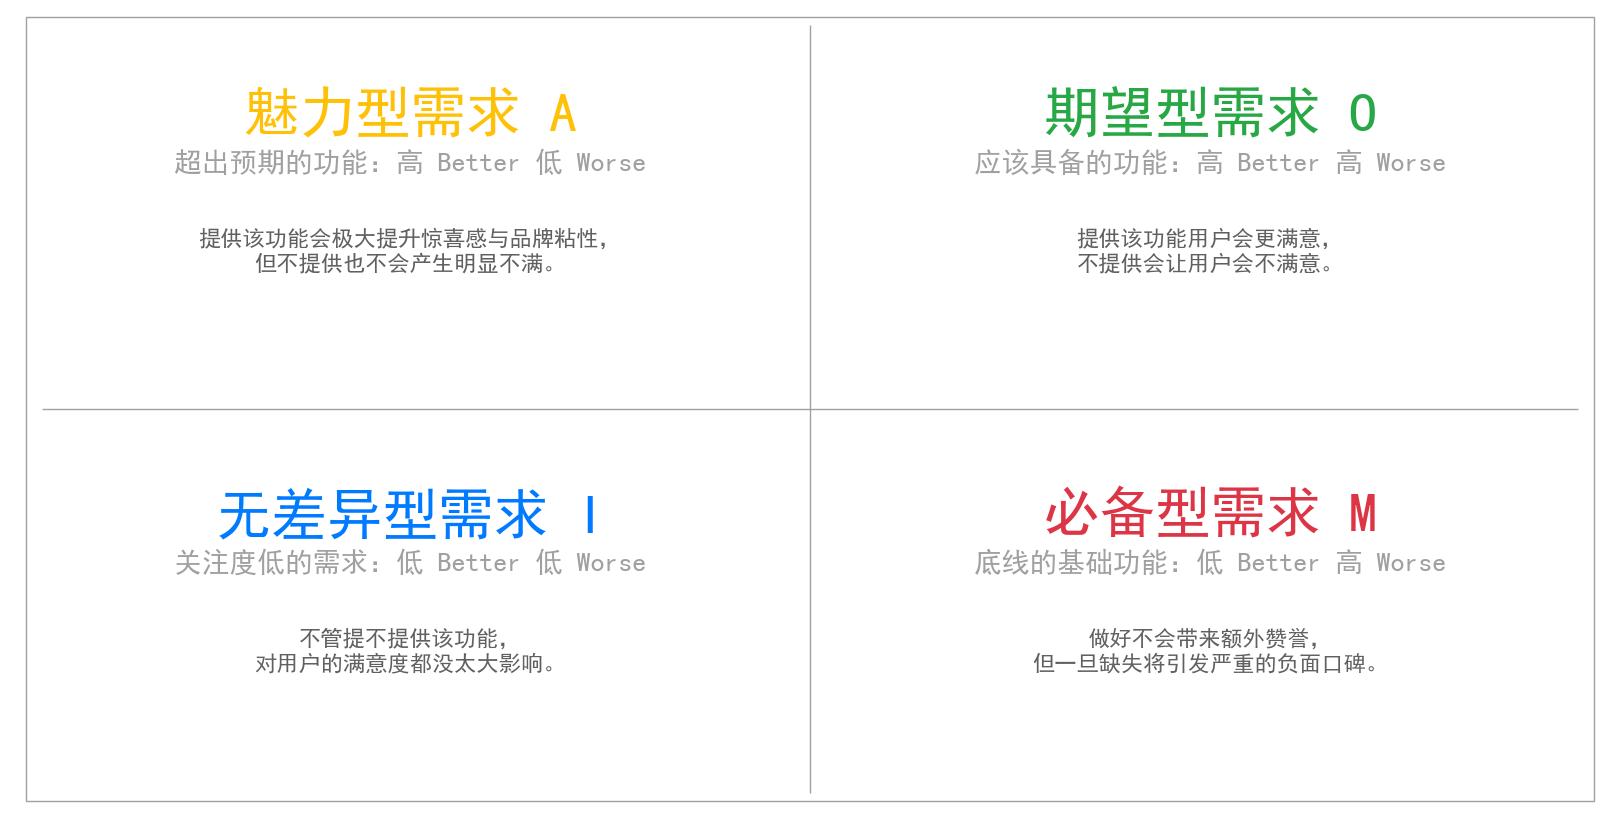

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm

IMAGE_WIDTH = 16        # 图像宽度 (默认 12 英寸)
IMAGE_HEIGHT = 8        # 图像高度 (默认 8 英寸)

TITLE_FONT_SIZE = 40    # 主标题字号 (例如："兴奋型属性")
SUBTITLE_FONT_SIZE = 20 # 副标题字号 (例如："应该具备的功能")
DESC_FONT_SIZE = 16     # 描述文字字号 (例如："提供该功能会让用户...")

# 1. 尝试寻找支持中文的系统字体
def find_chinese_fonts():
    possible_fonts = ['SimHei', 'Microsoft YaHei', 'Noto Sans CJK SC', 'Droid Sans Fallback', 'PingFang SC', 'AR PL UKai CN']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    for f in possible_fonts:
        if f in available_fonts:
            return f
    return None

chinese_font_name = find_chinese_fonts()
if not chinese_font_name:
    print("警告：未找到常用中文字体，中文可能会显示为乱码。请确保安装了如 'SimHei' 或 'Microsoft YaHei' 等字体。")
    # 默认使用一个通用字体，但效果取决于系统
    chinese_font_name = 'sans-serif' 

# 2. 定义四个象限的信息（标题、小标题、描述、用户代码和颜色）
# 文本内容提取自 image_0.png
# 颜色映射来源于用户指定
quadrants_info = [
    # Top-left (row=0, col=0)
    {
        'position': (0, 0),
        'title': '魅力型需求 A',
        'subtitle': '超出预期的功能：高 Better 低 Worse',
        'desc': '提供该功能会极大提升惊喜感与品牌粘性，\n但不提供也不会产生明显不满。',
        'code': 'O',
        'color': '#ffc107', # 黄色 - 魅力型 (兴奋型)
        'main_title_color': '#ffc107',
        'subtitle_color': '#a0a0a0', # 中性灰色
        'desc_color': '#606060'     # 较深灰色
    },
    # Top-right (row=0, col=1)
    {
        'position': (0, 1),
        'title': '期望型需求 O',
        'subtitle': '应该具备的功能：高 Better 高 Worse',
        'desc': '提供该功能用户会更满意，\n不提供会让用户会不满意。',
        'code': 'A',
        'color': '#28a745', # 绿色 - 期望型
        'main_title_color': '#28a745',
        'subtitle_color': '#a0a0a0',
        'desc_color': '#606060'
    },
    # Bottom-left (row=1, col=0)
    {
        'position': (1, 0),
        'title': '无差异型需求 I',
        'subtitle': '关注度低的需求：低 Better 低 Worse',
        'desc': '不管提不提供该功能，\n对用户的满意度都没太大影响。',
        'code': 'I',
        'color': '#007bff', # 蓝色 - 无差异型
        'main_title_color': '#007bff',
        'subtitle_color': '#a0a0a0',
        'desc_color': '#606060'
    },
    # Bottom-right (row=1, col=1)
    {
        'position': (1, 1),
        'title': '必备型需求 M',
        'subtitle': '底线的基础功能：低 Better 高 Worse',
        'desc': '做好不会带来额外赞誉，\n但一旦缺失将引发严重的负面口碑。',
        'code': 'M',
        'color': '#dc3545', # 红色 - 必备型
        'main_title_color': '#dc3545',
        'subtitle_color': '#a0a0a0',
        'desc_color': '#606060'
    }
]

# 3. 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(IMAGE_WIDTH, IMAGE_HEIGHT))
ax.set_axis_off()  # 隐藏坐标轴和刻度线
ax.set_xlim(0, 1)  # 设置逻辑坐标范围 x
ax.set_ylim(0, 1)

# 4. 设置字体属性。使用具体的 FontProperties 会比全局 rcParams 更加健壮
# 需要确保系统有支持中文的字体。Bold加粗可能需要特定的字体文件支持。
FONT_PROP_BOLD = fm.FontProperties(family=chinese_font_name, size=TITLE_FONT_SIZE, weight='bold')
FONT_PROP_REG = fm.FontProperties(family=chinese_font_name, size=SUBTITLE_FONT_SIZE)
FONT_PROP_DESC = fm.FontProperties(family=chinese_font_name, size=DESC_FONT_SIZE)

# 5. 绘制分割线和外部边框
# 遵循图片布局
ax.vlines(0.5, 0.02, 0.98, colors='#a0a0a0', linestyles='-', linewidth=1) 
ax.hlines(0.5, 0.02, 0.98, colors='#a0a0a0', linestyles='-', linewidth=1)

# 在图周围添加一个大框框
outer_rect = patches.Rectangle((0.01, 0.01), 0.98, 0.98, fill=False, edgecolor='#a0a0a0', linewidth=1)
ax.add_patch(outer_rect)

# 6. 绘制文本和可选的彩色填充框
for info in quadrants_info:
    row, col = info['position']
    # 计算在 0.5 宽度的框内的中心逻辑坐标
    x = col * 0.5 + 0.25 # center x
    y = (1 - row) * 0.5 + 0.25 # center y (flip row for y coordinate from top-left logic)

    # 可选：绘制半透明彩色矩形框作为背景（如果需要，请取消注释）
    # rect = patches.Rectangle((x - 0.24, y - 0.24), 0.48, 0.48, facecolor=info['color'], alpha=0.05, edgecolor='none')
    # ax.add_patch(rect)
    
    # 绘制文本
    # 标题 (加粗, 对应颜色)
    ax.text(x, y + 0.12, info['title'], ha='center', va='center', fontproperties=FONT_PROP_BOLD, color=info['main_title_color'])
    # 小标题 (常规, 中性灰)
    ax.text(x, y + 0.06, info['subtitle'], ha='center', va='center', fontproperties=FONT_PROP_REG, color=info['subtitle_color'])
    # 描述文本 (常规, 较深灰, ha='center', 支持多行)
    ax.text(x, y - 0.05, info['desc'], ha='center', va='center', fontproperties=FONT_PROP_DESC, color=info['desc_color'])

# 7. 调整布局
plt.tight_layout(pad=0) # ensure no content is clipped

# 8. 绘制图形
plt.show() # 直接显示。如果在生产环境，通常使用 fig.savefig()。

In [ ]:
from graphviz import Digraph

def create_flowchart():
    # 实例化一个有向图对象，设置输出格式为高清晰度的 png 或 pdf
    dot = Digraph(name="Kano_Entropy_TOPSIS_Flow", format="png")
    
    # 全局属性设置
    # 设置分辨率为 300 dpi 以满足打印和报告的高清要求
    # rankdir='TB' 表示从上到下 (Top to Bottom) 布局
    dot.attr(dpi='300', rankdir='LR')
    
    # 节点全局样式设置 (确保你的电脑安装了该中文字体，如 Windows 的 Microsoft YaHei 或 Mac 的 PingFang SC)
    dot.attr('node', 
             shape='rect', 
             style='rounded,filled', 
             fillcolor='#FFFFFF',     # 浅蓝色背景，显得专业且干净F0F8FF
             color='#000000',         # 边框颜色 (钢蓝色)4682B4
             fontname='Microsoft YaHei', 
             fontsize='14',
             penwidth='2',
             margin='0.4,0.2')        # 节点内边距，让文字周围有呼吸感
             
    # 连线全局样式设置
    dot.attr('edge', 
             color='#555555', 
             penwidth='1.5',
             arrowsize='0.8')

    # 1. 定义流程节点
    dot.node('Step1', 'KANO\n模型分析')
    dot.node('Step2', '构造评价指标矩阵：\nBetter, Worse, O占比, \nM占比, A占比')
    dot.node('Step3', '熵权法\n计算指标权重')
    dot.node('Step4', 'TOPSIS \n欧式距离排序')
    dot.node('Step5', '输出\n综合重要度得分')

    # 2. 建立连线关系 (严格按照你的精简逻辑)
    dot.edges([('Step1', 'Step2'), 
               ('Step2', 'Step3'), 
               ('Step3', 'Step4'), 
               ('Step4', 'Step5')])

    # 3. 渲染并保存文件
    # 将在当前运行目录下生成一个名为 'kano_methodology_flow.png' 的文件
    # view=True 会在生成后自动调用系统默认图片查看器打开它
    output_path = dot.render('kano_methodology_flow', view=True)
    print(f"流程图已成功生成并保存在: {output_path}")

if __name__ == '__main__':
    create_flowchart()

# 随机森林

In [139]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [140]:
# 0. 环境设置与基础准备
# ==========================================
# 读取数据
print("正在读取数据...")
df = pd.read_csv('data_ascend.csv')

# 仅保留有效问卷
df = df[df['问卷状态'] == '有效']

# 17 个属性名称及对应的列名
attr_names = [
    '食材新鲜可靠', '健康属性解释', '配料信息标注', '门店售后服务', '包装操作方便',
    '口味与饱腹感', '高性价比', '渠道容易获取', '饮食愉悦感', '产品搭配新颖',
    '社交平台口碑', '展现健康形象', '明星公众代言', '追赶饮食潮流', '优惠会员福利',
    '舒适就餐环境', '环保低碳包装'
]
X_cols = [f'Q32_{i+1}_市场满意度' for i, attr in enumerate(attr_names)]
y_col = 'Q32_总体满意度'

# 人群映射字典
cluster_map = {
    1: '高频健身塑形者',
    2: '潮流健康追求者',
    3: '理性价格权衡者',
    4: '便利导向尝鲜者'
}

# 用于存储结果的字典
metrics_results = {}
importance_dfs = []

# ==========================================
# 1. 分人群进行模型训练与评估
# ==========================================
for cluster_id, cluster_name in cluster_map.items():
    print(f"\n{'='*50}")
    print(f"🚀 正在分析人群: 【{cluster_name}】")
    print(f"{'='*50}")
    
    # 提取当前人群数据并去除含空值的行（防止报错）
    group_df = df[df['Persona_Cluster'] == cluster_id]
    group_df = group_df.dropna(subset=X_cols + [y_col])
    
    X = group_df[X_cols]
    y = group_df[y_col]
    
    print(f"有效样本量: {len(X)}")
    
    # 按 8:2 随机划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2026)
    
    # 定义随机森林模型
    rf = RandomForestRegressor(random_state=2026)
    
    # 设定 5折交叉验证 (5-fold CV) 的超参数网格
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 3, 5, 10],
        'min_samples_split': [2, 5]
    }
    
    print("正在进行 5折交叉验证 训练模型...")
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                               cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_rf = grid_search.best_estimator_
    
    # 模型预测 (在测试集上)
    y_pred = best_rf.predict(X_test)
    
    # 计算评估指标
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    metrics_results[cluster_name] = {'MAE': mae, 'MSE': mse, 'R²': r2}
    print(f"✅ 模型评估结果 -> MAE: {mae:.4f} | MSE: {mse:.4f} | R²: {r2:.4f}")
    
    # ==========================================
    # 2. 计算排列重要性 (Permutation Importance)
    # ==========================================
    # 注意：排列重要性必须在测试集上计算，以反映真实的泛化特征权重
    perm_importance = permutation_importance(best_rf, X_test, y_test, 
                                             n_repeats=10, random_state=2026, n_jobs=-1)
    
    # 整理重要性数据
    imp_df = pd.DataFrame({
        '属性': attr_names,
        '重要性得分': perm_importance.importances_mean,
        '标准差': perm_importance.importances_std,
        '人群': cluster_name
    })
    
    # 按重要性降序排序
    imp_df = imp_df.sort_values(by='重要性得分', ascending=False).reset_index(drop=True)
    importance_dfs.append(imp_df)
    
    # ==========================================
    # 3. 绘制并保存排列重要性条形图
    # ==========================================
    plt.figure(figsize=(10, 8))
    sns.barplot(x='重要性得分', y='属性', data=imp_df, palette='viridis')
    
    # 添加误差棒 (标准差)
    plt.errorbar(x=imp_df['重要性得分'], y=np.arange(len(imp_df)), 
                 xerr=imp_df['标准差'], fmt='none', c='black', capsize=4)
    
    #plt.title(f'排列重要性 (Permutation Importance) - {cluster_name}', fontsize=16, pad=15)
    plt.xlabel('特征对模型预测的贡献度 (R² 误差增加量)', fontsize=12)
    plt.ylabel('轻食需求属性', fontsize=12)
    
    # 在条形图上标注具体数值
    for index, value in enumerate(imp_df['重要性得分']):
        plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10)
        
    plt.tight_layout()
    plot_filename = f'Importance_Plot_{cluster_id}_{cluster_name}.png'
    plt.savefig(plot_filename, dpi=300)
    plt.close() # 关闭画布，避免重叠
    print(f"📊 已保存图表: {plot_filename}")

# ==========================================
# 4. 汇总输出评估指标与特征重要性表格
# ==========================================
print("\n" + "="*50)
print("🎯 最终模型效果汇总 (测试集表现)")
print("="*50)
metrics_df = pd.DataFrame(metrics_results).T
print(metrics_df.round(4))
metrics_df.to_csv('RF_Metrics_Summary.csv', encoding='utf-8-sig')

# 合并四个类的排列重要性表格（长表转宽表以便于阅读）
final_imp_df = pd.concat(importance_dfs, ignore_index=True)
pivot_imp_df = final_imp_df.pivot(index='属性', columns='人群', values='重要性得分')

# 计算所有人群的均值，并按均值降序排列
pivot_imp_df['综合均值'] = pivot_imp_df.mean(axis=1)
pivot_imp_df = pivot_imp_df.sort_values(by='综合均值', ascending=False)

print("\n" + "="*50)
print("🏆 四类人群的排列重要性得分对比 (节选)")
print("="*50)
print(pivot_imp_df.round(4).head(8)) # 打印前8个核心属性

# 导出为CSV
pivot_imp_df.to_csv('RF_Permutation_Importance_Table.csv', encoding='utf-8-sig')
print("\n✅ 所有分析完毕！表格已导出为 'RF_Metrics_Summary.csv' 和 'RF_Permutation_Importance_Table.csv'")

正在读取数据...

🚀 正在分析人群: 【高频健身塑形者】
有效样本量: 242
正在进行 5折交叉验证 训练模型...
✅ 模型评估结果 -> MAE: 0.3235 | MSE: 0.1970 | R²: 0.5424
📊 已保存图表: Importance_Plot_1_高频健身塑形者.png

🚀 正在分析人群: 【潮流健康追求者】
有效样本量: 132
正在进行 5折交叉验证 训练模型...
✅ 模型评估结果 -> MAE: 0.2606 | MSE: 0.1412 | R²: 0.7933
📊 已保存图表: Importance_Plot_2_潮流健康追求者.png

🚀 正在分析人群: 【理性价格权衡者】
有效样本量: 227
正在进行 5折交叉验证 训练模型...
✅ 模型评估结果 -> MAE: 0.2931 | MSE: 0.1691 | R²: 0.6544
📊 已保存图表: Importance_Plot_3_理性价格权衡者.png

🚀 正在分析人群: 【便利导向尝鲜者】
有效样本量: 150
正在进行 5折交叉验证 训练模型...
✅ 模型评估结果 -> MAE: 0.3190 | MSE: 0.1942 | R²: 0.5038
📊 已保存图表: Importance_Plot_4_便利导向尝鲜者.png

🎯 最终模型效果汇总 (测试集表现)
            MAE     MSE      R²
高频健身塑形者  0.3235  0.1970  0.5424
潮流健康追求者  0.2606  0.1412  0.7933
理性价格权衡者  0.2931  0.1691  0.6544
便利导向尝鲜者  0.3190  0.1942  0.5038

🏆 四类人群的排列重要性得分对比 (节选)
人群      便利导向尝鲜者  潮流健康追求者  理性价格权衡者  高频健身塑形者    综合均值
属性                                                
产品搭配新颖  -0.0028   0.6694   0.0027   0.0025  0.1680
食材新鲜可靠   0.0009   0.0063   0.0593   0.5426  0.1523
渠道容易获取   0.5689

# IPA

正在读取调查问卷与随机森林重要性数据...

🚀 正在生成【高频健身塑形者】的 IPA 矩阵图...
✅ 图表已保存为 IPA_Matrix_RF_高频健身塑形者.png


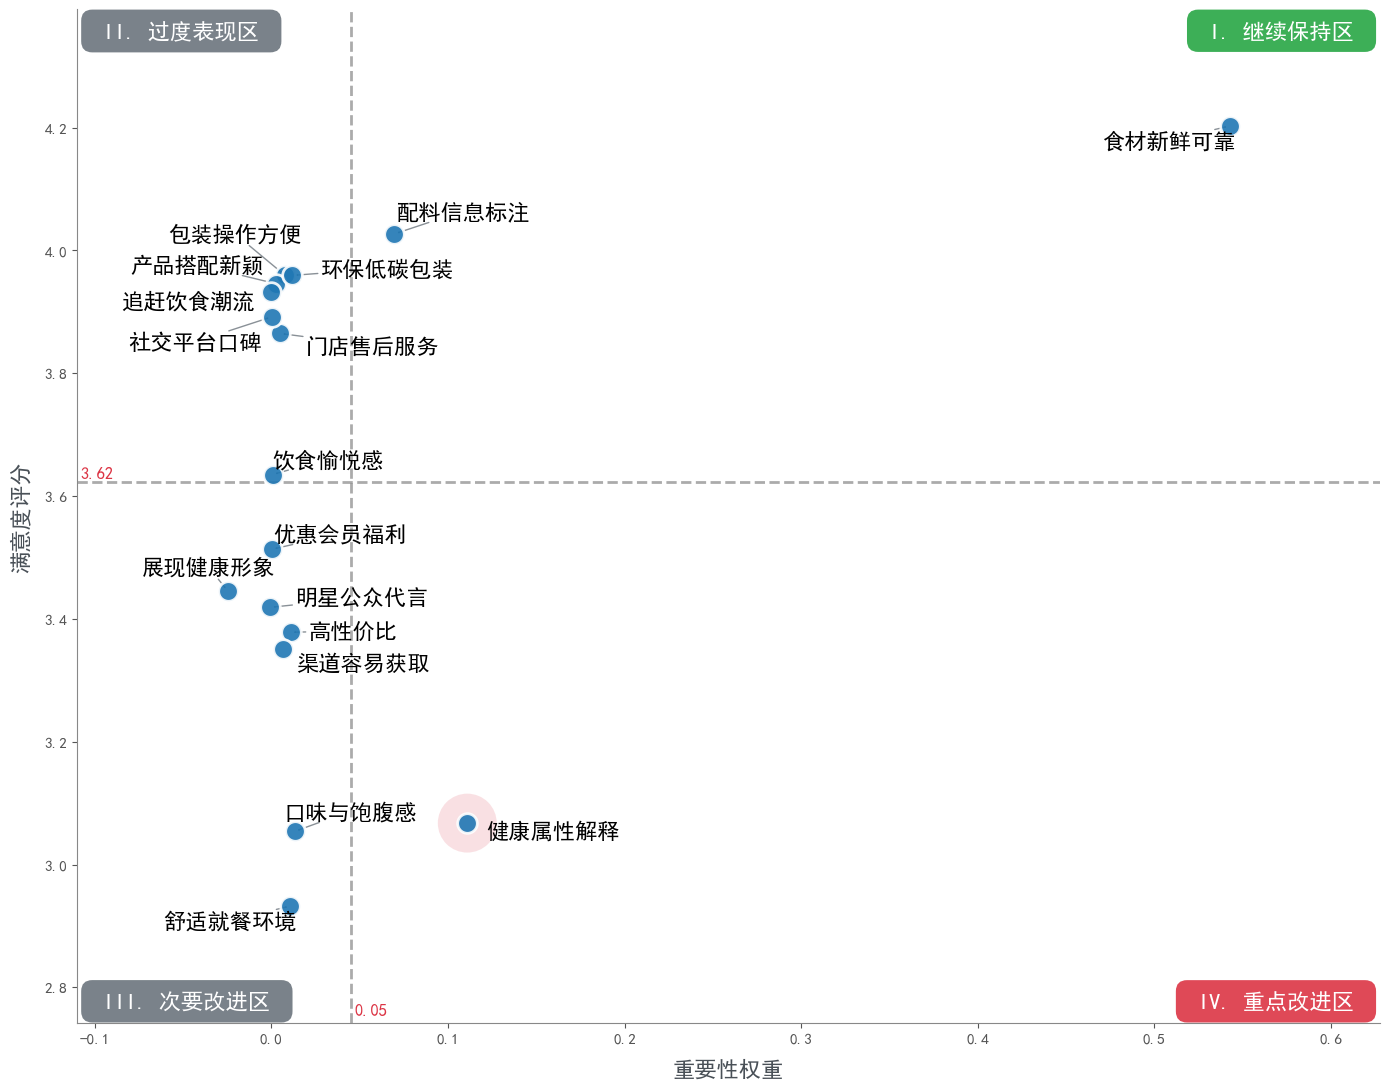

   🚨 【高频健身塑形者】的重点改进区痛点 (急需资源倾斜):
       - 健康属性解释 (重要度: 0.11, 满意度: 3.07)

🚀 正在生成【潮流健康追求者】的 IPA 矩阵图...
✅ 图表已保存为 IPA_Matrix_RF_潮流健康追求者.png


<Figure size 640x480 with 0 Axes>

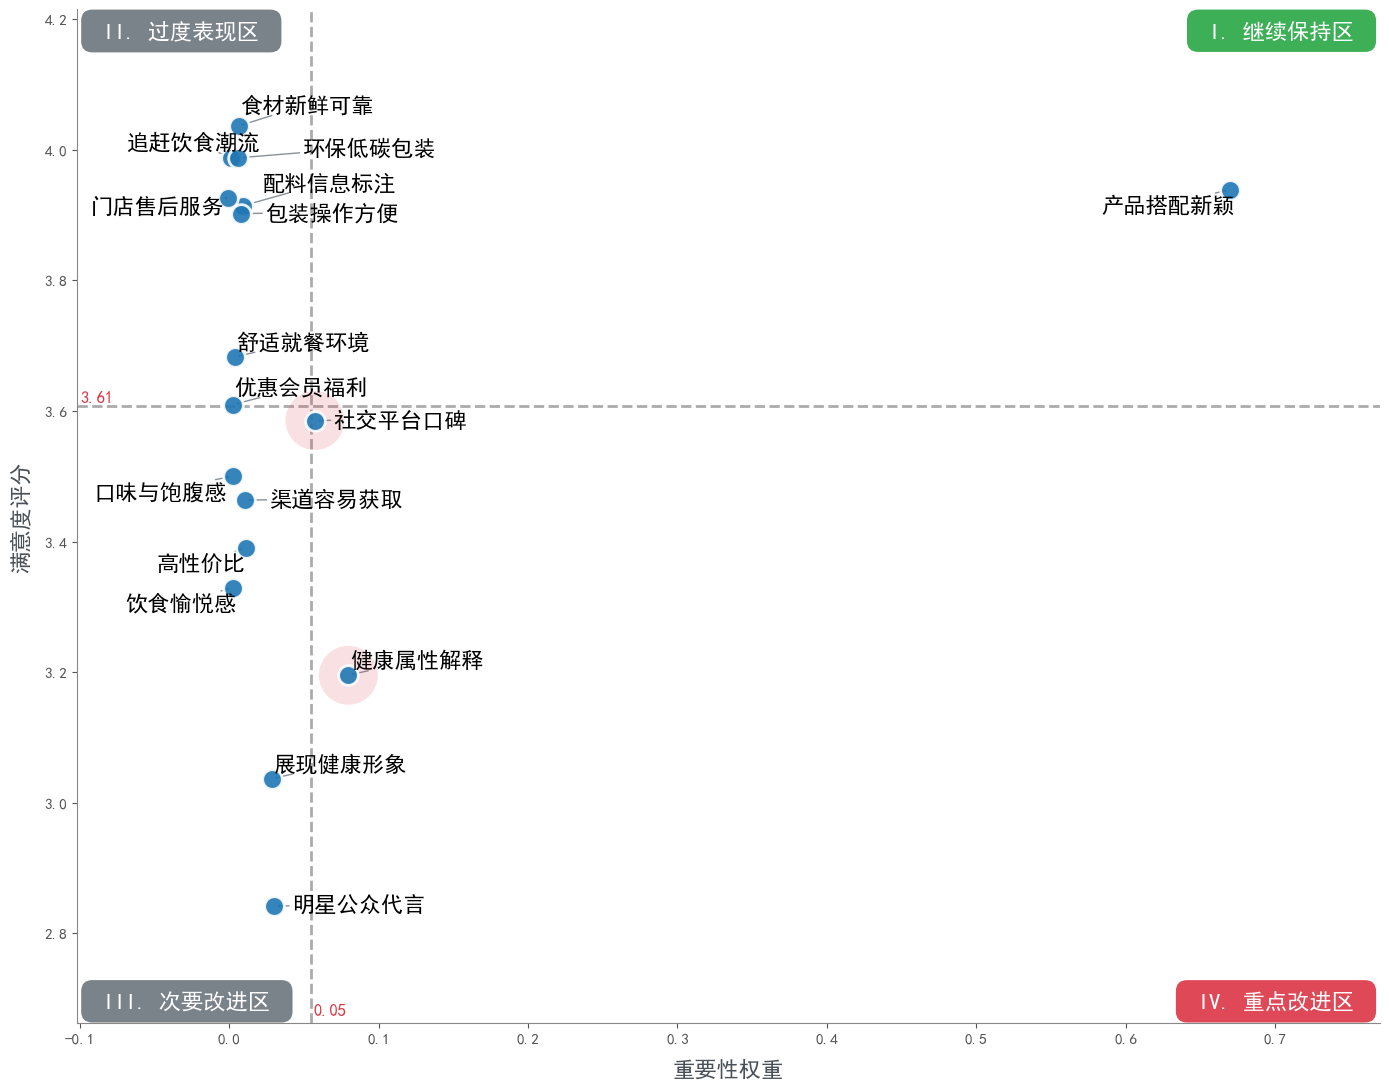

   🚨 【潮流健康追求者】的重点改进区痛点 (急需资源倾斜):
       - 健康属性解释 (重要度: 0.08, 满意度: 3.20)

🚀 正在生成【理性价格权衡者】的 IPA 矩阵图...
✅ 图表已保存为 IPA_Matrix_RF_理性价格权衡者.png


<Figure size 640x480 with 0 Axes>

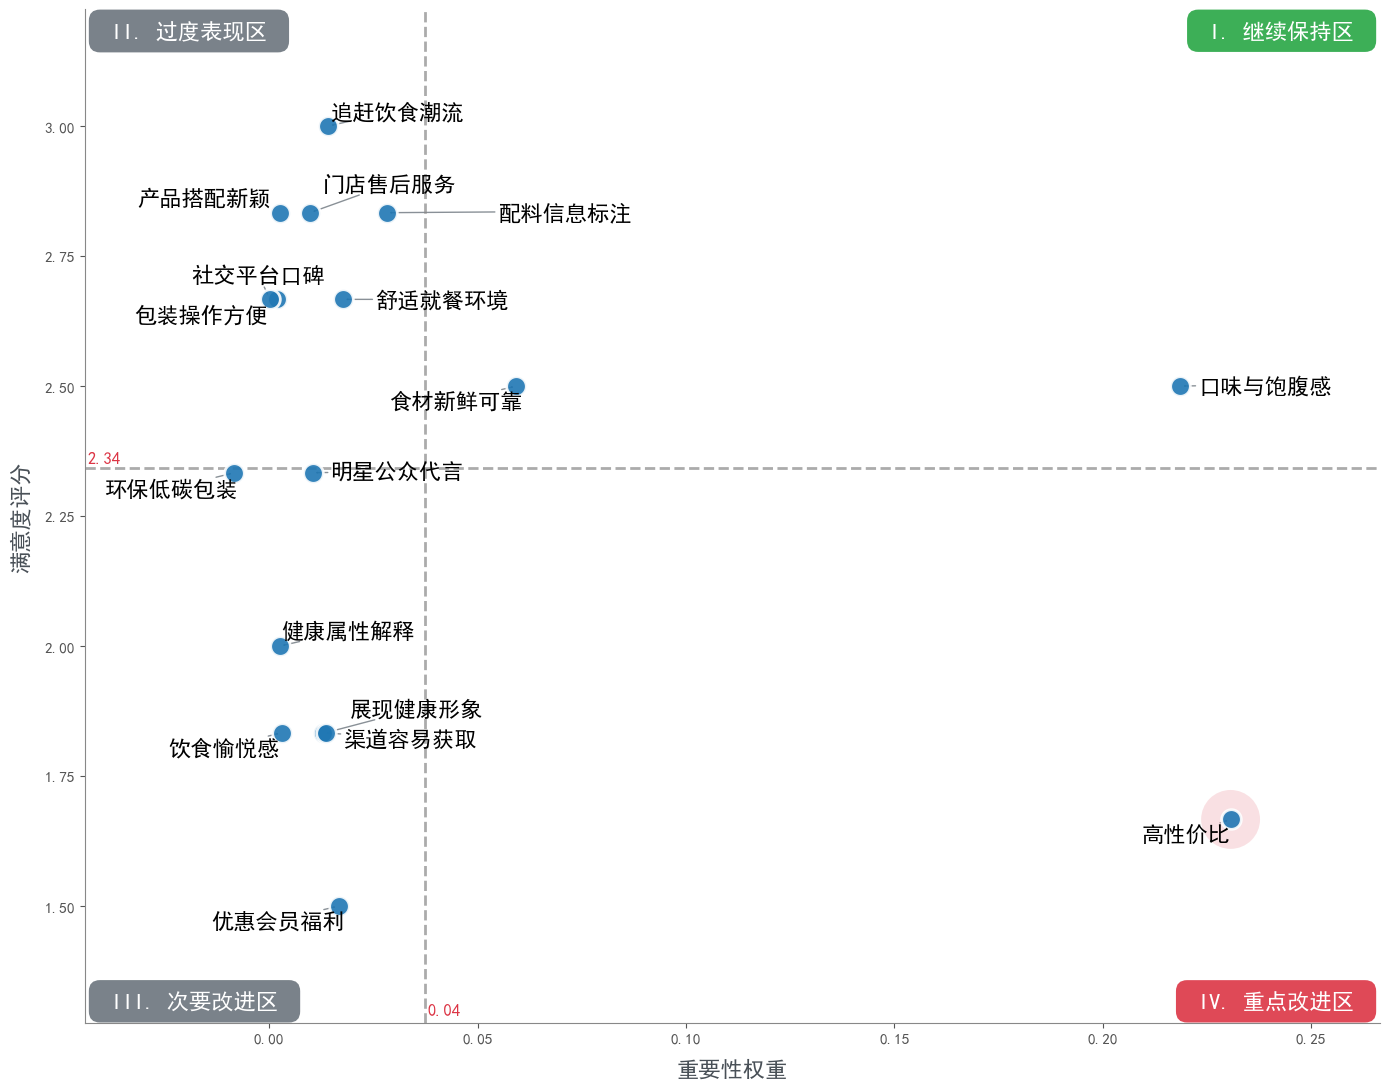

   🚨 【理性价格权衡者】的重点改进区痛点 (急需资源倾斜):
       - 高性价比 (重要度: 0.23, 满意度: 1.67)
       - 口味与饱腹感 (重要度: 0.22, 满意度: 2.50)
       - 食材新鲜可靠 (重要度: 0.06, 满意度: 2.50)

🚀 正在生成【便利导向尝鲜者】的 IPA 矩阵图...
0 [ 0.8907171 -0.3516208]
9 [ 0.56336759 -0.36113904]
✅ 图表已保存为 IPA_Matrix_RF_便利导向尝鲜者.png


<Figure size 640x480 with 0 Axes>

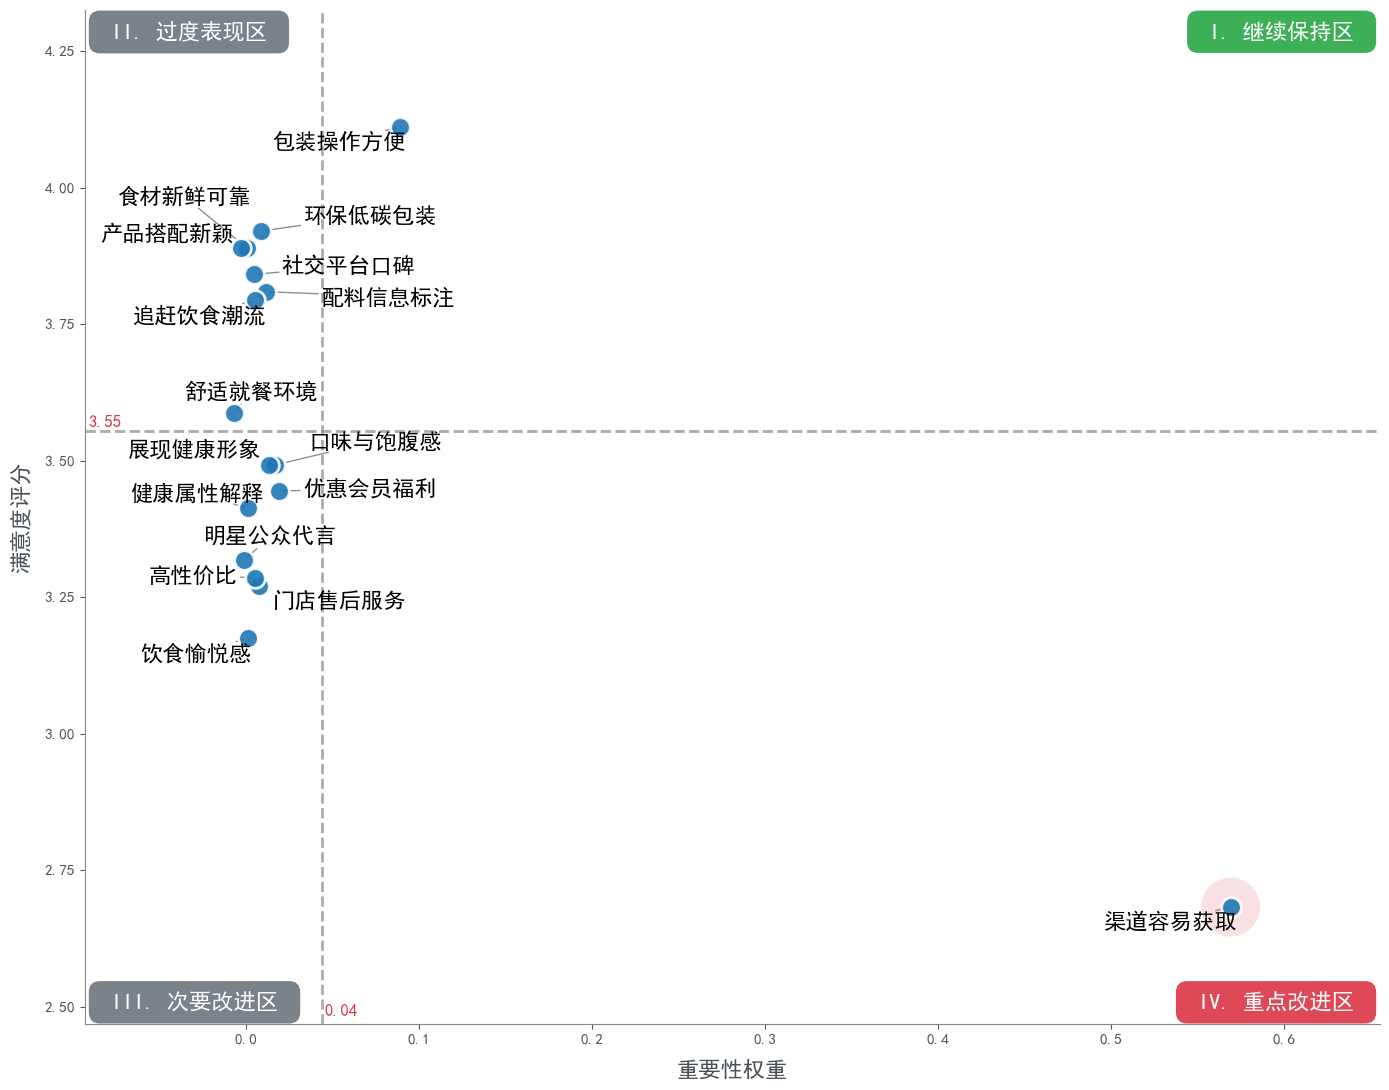

   🚨 【便利导向尝鲜者】的重点改进区痛点 (急需资源倾斜):
       - 渠道容易获取 (重要度: 0.57, 满意度: 2.68)


<Figure size 640x480 with 0 Axes>

In [143]:
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("提示：建议安装 adjustText 库以防止文字重叠 (!pip install adjustText)")

# ==========================================
# 0. 环境设置与数据准备
# ==========================================
print("正在读取调查问卷与随机森林重要性数据...")
# 1. 读取问卷源数据 (计算 Performance)
df_valid = pd.read_csv('data_ascend.csv', encoding='utf-8-sig')
df_valid = df_valid[df_valid['问卷状态'] == '有效']

# 2. 读取随机森林重要性数据 (计算 Importance)
df_rf = pd.read_csv('RF_Permutation_Importance_Table.csv', encoding='utf-8-sig')

# 确保 17 个属性的名称与之前代码严格一致
attr_names = [
    '食材新鲜可靠', '健康属性解释', '配料信息标注', '门店售后服务', '包装操作方便',
    '口味与饱腹感', '高性价比', '渠道容易获取', '饮食愉悦感', '产品搭配新颖',
    '社交平台口碑', '展现健康形象', '明星公众代言', '追赶饮食潮流', '优惠会员福利',
    '舒适就餐环境', '环保低碳包装'
]

cluster_map = {
    1: '高频健身塑形者',
    2: '潮流健康追求者',
    3: '理性价格权衡者',
    4: '便利导向尝鲜者'
}

# 仅筛选出真正购买过 KPRO 的消费者以计算真实的 Performance（满意度）
kpro_users = df_valid[df_valid['Q35_买过KPRO'] == '是']

# ==========================================
# 1. 分人群执行 IPA 分析与绘图
# ==========================================
for cluster_id, group_name in cluster_map.items():
    print(f"\n{'='*50}")
    print(f"🚀 正在生成【{group_name}】的 IPA 矩阵图...")
    print(f"{'='*50}")
    
    # 提取当前人群的 KPRO 消费者数据
    group_kpro_users = kpro_users[kpro_users['Persona_Cluster'] == cluster_id]
    
    if len(group_kpro_users) == 0:
        print(f"⚠️ 警告：{group_name} 中没有购买过 KPRO 的用户，跳过该人群。")
        continue

    ipa_data = []

    # 提取 RF 得分作为 Importance，并计算真实的 Performance
    for i, attr in enumerate(attr_names):
        # 匹配对应 Q37 列名
        q37_col_name = f'Q37_{i+1}_KPRO满意度'
        
        # 获取 Importance (从 RF 宽表中提取当前人群的列)
        if attr in df_rf['属性'].values:
            importance_score = df_rf.loc[df_rf['属性'] == attr, group_name].values[0]
        else:
            importance_score = np.nan
        
        # 获取 Performance (满意度均值)
        if q37_col_name in group_kpro_users.columns:
            performance_score = group_kpro_users[q37_col_name].mean()
        else:
            performance_score = np.nan
            
        ipa_data.append({
            '属性名称': attr,
            'Importance (RF)': importance_score,
            'Performance (Q37)': performance_score
        })

    df_ipa = pd.DataFrame(ipa_data).dropna()

    # ==========================================
    # 2. 绘制带坐标轴与重点高亮的高级 IPA 图
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 11))

    x = df_ipa['Importance (RF)']
    y = df_ipa['Performance (Q37)']
    labels = df_ipa['属性名称'].tolist()

    # 此处采用【实际均值法】确定分界线
    x_threshold = x.mean()
    y_threshold = y.mean()

    # 绘制基础散点
    ax.scatter(x, y, s=200, c='#1f77b4', edgecolor='white', linewidth=2, alpha=0.9, zorder=4)

    # 🌟 新增：为第四象限 (重要度 > 均值 且 满意度 < 均值) 的点添加醒目的浅色高亮范围圆
    q4_mask = (x > x_threshold) & (y < y_threshold)
    if q4_mask.any():
        ax.scatter(x[q4_mask], y[q4_mask], s=1800, c='#dc3545', alpha=0.15, zorder=3, edgecolors='none')

    # 绘制十字交叉虚线
    ax.axvline(x=x_threshold, color='#888888', linestyle='--', linewidth=2, alpha=0.7, zorder=2)
    ax.axhline(y=y_threshold, color='#888888', linestyle='--', linewidth=2, alpha=0.7, zorder=2)

    # 🌟 新增：在十字分界线旁标注具体的分界数字
    # 获取当前坐标轴的显示范围以定位文本
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    padding_x = (x_max - x_min) * 0.15 if x_max != x_min else 0.5
    padding_y = (y_max - y_min) * 0.15 if y_max != y_min else 0.5
    
    ax.set_xlim(x_min - padding_x, x_max + padding_x)
    ax.set_ylim(y_min - padding_y, y_max + padding_y)

    # 在靠近坐标轴边缘的位置标出分界值
    ax.text(x_threshold + padding_x*0.02, ax.get_ylim()[0] + padding_y*0.05, f'{x_threshold:.2f}', 
            color='#dc3545', fontsize=12, fontweight='bold', va='bottom', ha='left', zorder=3)
    ax.text(ax.get_xlim()[0] + padding_x*0.02, y_threshold + padding_y*0.02, f'{y_threshold:.2f}', 
            color='#dc3545', fontsize=12, fontweight='bold', va='bottom', ha='left', zorder=3)

    # 恢复坐标轴显示，但保持清爽风格
    #ax.set_facecolor('#fafafa') # 轻微的灰色背景
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#888888')
    ax.spines['bottom'].set_color('#888888')
    ax.tick_params(axis='x', colors='#555555', labelsize=11)
    ax.tick_params(axis='y', colors='#555555', labelsize=11)

    # 坐标轴标签
    ax.set_xlabel('重要性权重', fontsize=16, fontweight='bold', color='#495057', labelpad=10)
    ax.set_ylabel('满意度评分', fontsize=16, fontweight='bold', color='#495057', labelpad=10)

    # 绘制四大象限的彩色背景提示区
    bbox_style = dict(boxstyle='round,pad=0.5', alpha=0.9)
    ax.text(ax.get_xlim()[1] - padding_x*0.1, ax.get_ylim()[1] - padding_y*0.1, ' I. 继续保持区 ', 
            fontsize=16, color='white', fontweight='bold', ha='right', va='top', zorder=1,
            bbox=dict(facecolor='#28a745', edgecolor='none', **bbox_style))
    ax.text(ax.get_xlim()[0] + padding_x*0.1, ax.get_ylim()[1] - padding_y*0.1, ' II. 过度表现区 ', 
            fontsize=16, color='white', fontweight='bold', ha='left', va='top', zorder=1,
            bbox=dict(facecolor='#6c757d', edgecolor='none', **bbox_style))
    ax.text(ax.get_xlim()[0] + padding_x*0.1, ax.get_ylim()[0] + padding_y*0.1, ' III. 次要改进区 ', 
            fontsize=16, color='white', fontweight='bold', ha='left', va='bottom', zorder=1,
            bbox=dict(facecolor='#6c757d', edgecolor='none', **bbox_style))
    ax.text(ax.get_xlim()[1] - padding_x*0.1, ax.get_ylim()[0] + padding_y*0.1, ' IV. 重点改进区 ', 
            fontsize=16, color='white', fontweight='bold', ha='right', va='bottom', zorder=1,
            bbox=dict(facecolor='#dc3545', edgecolor='none', **bbox_style))

    # 执行文字防重叠算法
    texts = []
    for j, label in enumerate(labels):
        texts.append(ax.text(x.iloc[j], y.iloc[j], label, fontsize=16, fontweight='bold', 
                             ha='center', va='center', zorder=5))
                             #bbox=dict(facecolor='white', edgecolor='#cccccc', alpha=0.8, pad=0.3, boxstyle='round,pad=0.3')))
    if HAS_ADJUST_TEXT:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-|>", color='#6c757d', lw=1, alpha=0.8))

    #x.set_title(f'KPRO 品牌 IPA 战略诊断矩阵 - 【{group_name}】', fontsize=22, fontweight='bold', pad=20)

    plt.tight_layout()
    filename = f'IPA_Matrix_RF_{group_name}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"✅ 图表已保存为 {filename}")

    plt.show()
    plt.clf()
    
    # 打印该人群的前 5 个急需改进(第四象限)的痛点
    quadrant4 = df_ipa[(df_ipa['Importance (RF)'] > mean_importance) & (df_ipa['Performance (Q37)'] < mean_performance)]
    quadrant4 = quadrant4.sort_values(by='Importance (RF)', ascending=False)
    
    if not quadrant4.empty:
        print(f"   🚨 【{group_name}】的重点改进区痛点 (急需资源倾斜):")
        for idx, row in quadrant4.iterrows():
            print(f"       - {row['属性名称']} (重要度: {row['Importance (RF)']:.2f}, 满意度: {row['Performance (Q37)']:.2f})")
    else:
        print(f"   👍 【{group_name}】的重点改进区目前没有明显痛点。")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False
    print("提示：建议安装 adjustText 库以防止文字重叠")

# ==========================================
# 0. 环境设置与读取数据
# ==========================================
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

# 读取随机森林重要性得分
try:
    df_rf = pd.read_csv('ipa_分析数据.csv', encoding='utf-8-sig') # 如果报错可以尝试 encoding='gbk'
except FileNotFoundError:
    df_rf = pd.read_csv('ipa_分析数据.csv')

# 假设 df_valid 已经在您的环境中存在
kpro_users = df_valid[df_valid['Q35_买过KPRO'] == '是']

# ==========================================
# 1. 映射字典：提取核心对应属性
# ==========================================
q37_mapping = {
    '口味与饱腹感': 'Q37_1_KPRO满意度',       # 请替换为您实际的列名，如 'Q37_1'
    '健康属性解释': 'Q37_2_KPRO满意度',
    '食材新鲜可靠': 'Q37_3_KPRO满意度',
    '产品搭配新颖': 'Q37_4_KPRO满意度',
    '包装操作方便': 'Q37_5_KPRO满意度',
    '渠道容易获取': 'Q37_6_KPRO满意度',
    '高性价比': 'Q37_7_KPRO满意度',
    '优惠会员福利': 'Q37_8_KPRO满意度',
    '门店售后服务': 'Q37_9_KPRO满意度',
    '配料信息标注': 'Q37_11_KPRO满意度',
    '追赶饮食潮流': 'Q37_15_KPRO满意度',
    '明星公众代言': 'Q37_17_KPRO满意度',
    '舒适就餐环境': 'Q37_18_KPRO满意度'
}

# ==========================================
# 2. 提取 Importance (随机森林) 和 Performance (满意度)
# ==========================================
ipa_data = []

for feature, q37_col_name in q37_mapping.items():
    # 1. 获取重要性 (从随机森林输出的 csv 中读取)
    if feature in df_rf['属性'].values:
        importance_score = df_rf.loc[df_rf['属性'] == feature, '平均重要性'].values[0]
    else:
        print(f"警告：未在 ipa_分析数据.csv 中找到 {feature}，该项将被跳过。")
        continue
        
    # 2. 获取表现度 (从原始问卷计算均值)
    if q37_col_name in kpro_users.columns:
        performance_score = kpro_users[q37_col_name].mean()
    else:
        performance_score = np.nan
        print(f"警告：未在问卷数据中找到列 {q37_col_name}！")
        
    ipa_data.append({
        '属性名称': feature,
        'Importance (RF)': importance_score,
        'Performance (Satisfaction)': performance_score
    })

df_ipa = pd.DataFrame(ipa_data).dropna()

# ==========================================
# 3. 绘制高级 IPA 四象限散点图 (Random Forest 版)
# ==========================================
fig, ax = plt.subplots(figsize=(16, 12))

x = df_ipa['Importance (RF)']
y = df_ipa['Performance (Satisfaction)']
labels = df_ipa['属性名称'].tolist()

# 绘制散点 (深蓝色商务风)
scatter = ax.scatter(x, y, s=220, c='#1f77b4', edgecolor='white', linewidth=2.5, alpha=0.85, zorder=4)

# 计算整体均值作为十字交叉线（传统 IPA 做法）
mean_importance = x.mean()
mean_performance = y.mean()

# 绘制十字交叉虚线
ax.axvline(x=mean_importance, color='#6c757d', linestyle='--', linewidth=2, alpha=0.8, zorder=2)
ax.axhline(y=mean_performance, color='#6c757d', linestyle='--', linewidth=2, alpha=0.8, zorder=2)

# --- 核心美化：去除外边框，设定纯白背景 ---
#ax.set_facecolor('#ffffff')
#for spine in ['top', 'right', 'left', 'bottom']:
#    ax.spines[spine].set_visible(False)
#ax.set_xticks([])
#ax.set_yticks([])

# 动态扩展坐标轴边缘以防内容溢出
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
padding_x = (x_max - x_min) * 0.15
padding_y = (y_max - y_min) * 0.15
ax.set_xlim(x_min - padding_x, x_max + padding_x)
ax.set_ylim(y_min - padding_y, y_max + padding_y)

# 坐标轴中心文字标识
ax.text(ax.get_xlim()[1] - 0.005, mean_performance - 0.015, 'Importance (随机森林平均重要性) ', 
        fontsize=13, color='#495057', fontweight='bold', ha='right', va='top', zorder=3)
ax.text(mean_importance - 0.005, ax.get_ylim()[1] - 0.01, 'Performance (KPRO 品牌满意度均值) ', 
        fontsize=13, color='#495057', fontweight='bold', ha='right', va='top', rotation=90, zorder=3)

# --- 绘制四大象限的彩色背景提示区 ---
bbox_style = dict(boxstyle='round,pad=0.6', alpha=0.9)

# 象限一：继续保持区 (高重要，高表现) - 右上
ax.text(ax.get_xlim()[1] - 0.02, ax.get_ylim()[1] - 0.02, ' 【继续保持区】\n (巩固核心优势) ', 
        fontsize=15, color='white', fontweight='bold', ha='right', va='top', zorder=1,
        bbox=dict(facecolor='#28a745', edgecolor='none', **bbox_style))

# 象限二：过度表现区 (低重要，高表现) - 左上
ax.text(ax.get_xlim()[0] + 0.02, ax.get_ylim()[1] - 0.02, ' 【过度表现区】\n (考虑削减预算) ', 
        fontsize=15, color='white', fontweight='bold', ha='left', va='top', zorder=1,
        bbox=dict(facecolor='#6c757d', edgecolor='none', **bbox_style))

# 象限三：次要改进区 (低重要，低表现) - 左下
ax.text(ax.get_xlim()[0] + 0.02, ax.get_ylim()[0] + 0.02, ' 【次要改进区】\n (暂缓资源投入) ', 
        fontsize=15, color='white', fontweight='bold', ha='left', va='bottom', zorder=1,
        bbox=dict(facecolor='#6c757d', edgecolor='none', **bbox_style))

# 象限四：重点改进区 (高重要，低表现) - 右下 (最危险的区域，红色警示)
ax.text(ax.get_xlim()[1] - 0.02, ax.get_ylim()[0] + 0.02, ' 【重点改进区】\n (亟需资源倾斜) ', 
        fontsize=15, color='white', fontweight='bold', ha='right', va='bottom', zorder=1,
        bbox=dict(facecolor='#dc3545', edgecolor='none', **bbox_style))

# --- 执行 adjustText 文字防重叠算法 ---
texts = []
for j, label in enumerate(labels):
    texts.append(ax.text(x.iloc[j], y.iloc[j], label, fontsize=13, fontweight='bold', 
                         ha='center', va='center', zorder=5,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.3)))

if HAS_ADJUST_TEXT:
    adjust_text(texts, ax=ax, 
                arrowprops=dict(arrowstyle="-|>", color='#6c757d', lw=1.2, alpha=0.8),
                expand_points=(2.5, 2.5), expand_text=(1.5, 1.5), force_text=(0.7, 0.7))

#ax.set_title('KPRO 品牌 IPA 战略诊断矩阵 (Kano-TOPSIS 映射法)', fontsize=24, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('IPA_Matrix_KPRO_TOPSIS.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ IPA 分析完成！高级诊断矩阵图已保存为 IPA_Matrix_KPRO_TOPSIS.png")
plt.show()

# ==========================================
# 3. 输出数据表供撰写报告使用
# ==========================================
print("\n▼ KPRO 品牌 IPA 交叉诊断详细数据表 ▼")
print("-" * 65)
print(df_ipa.round(4).sort_values(by='Importance (TOPSIS)', ascending=False).to_string(index=False))
print("-" * 65)